Importar as bibliotecas necessárias

In [1]:
import timeit # Para medir o tempo de execução
import optuna # Para otimização de hiperparâmetros
start_time = timeit.default_timer() # Marcar o início do tempo
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np
from torchvision.utils import save_image
import matplotlib.pyplot as plt
# Definir o dispositivo (cuda se disponível, caso contrário CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
from scipy.stats import wasserstein_distance

import mplhep as hep
plt.style.use("default")
plt.style.use(hep.style.CMS)
plt.rcParams['font.size'] = 12 

cuda


In [2]:
def mass_func(data):
    data = torch.transpose(data, 0, 1)
    
    px = data[0] + data[1]
    py = data[2] + data[3]
    pz = data[4] + data[5]
    E = data[6] + data[7]

    m2 = E**2 - px**2 - py**2 - pz**2
    return m2

O próximo passo é carregar os dados de entrada. Os dados utilizados são valores de momento transversal dos píons e dos káons, partículas filha do méson D0. Inicialmente, os dados se encontram em um .txt, e devem ser transformados em um tensor no PyTorch. Além disso, os dados são normalizados para aumentar a estabilidade do treino e divididos em set de treino, validação e teste.

In [3]:
# Carregar os dados de entrada
data = np.loadtxt("./Data/data_1.txt")
#D0_data = np.loadtxt("data_D0_daughtersPx_Py_Pz_E_D0.txt")

tensor_data_denormalized = torch.tensor(data, dtype=torch.float32, device=device)
#D0_data = torch.tensor(D0_data, dtype=torch.float32, device=device)

nVar = tensor_data_denormalized.shape[1]
mass_D0 = 1.8648

def normalize(x):
    return (x - means) / (stds + 1e-8)

def denormalize(x):
    if isinstance(x, np.ndarray):
        return x * (stds.numpy() + 1e-8) + means.numpy()
    return x * (stds + 1e-8) + means

print(f"Shape do tensor: {tensor_data_denormalized.shape}")
print(f"Raw {tensor_data_denormalized.size()}, {type(tensor_data_denormalized)}")
print(f"Dados do crus: {tensor_data_denormalized}")
print(f"Número de variáveis de entrada: {nVar}")

# Divisão dos dados em treino, validação e teste
nTotal = tensor_data_denormalized.size(0)
nTrain = int(0.6 * nTotal)
nVal = int(0.2 * nTotal)
nTest = nTotal - nTrain - nVal
print(f"nTrain: {nTrain}, nVal: {nVal}, nTest: {nTest}")

x_train_raw = tensor_data_denormalized[:nTrain]
x_val_raw   = tensor_data_denormalized[nTrain:nTrain + nVal]
x_test_raw  = tensor_data_denormalized[nTrain + nVal:]

# Estatísticas APENAS do train set
means = x_train_raw.mean(dim=0)
stds  = x_train_raw.std(dim=0)


tensor_data = normalize(tensor_data_denormalized)
# Normalizar cada split separadamente
x_train = normalize(x_train_raw)
x_val   = normalize(x_val_raw)
x_test  = normalize(x_test_raw)

print(f"x_train: {x_train.size()}, x_val: {x_val.size()}, x_test: {x_test.size()}")

# DataLoaders
batch_size = 64
trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)
testloader  = DataLoader(x_test,  shuffle=False, batch_size=batch_size)

'''
x_train_phys = x_train_raw
c_train = torch.stack([
    x_train_phys[:, 0] + x_train_phys[:, 1],
    x_train_phys[:, 2] + x_train_phys[:, 3],
    x_train_phys[:, 4] + x_train_phys[:, 5],
    x_train_phys[:, 6] + x_train_phys[:, 7],
], dim=1)
c_means = c_train.mean(dim=0)
c_stds  = c_train.std(dim=0)
cVar = c_train.shape[1]
'''

Shape do tensor: torch.Size([40000, 8])
Raw torch.Size([40000, 8]), <class 'torch.Tensor'>
Dados do crus: tensor([[ 2.0096e-01,  9.3887e-01, -3.0833e+00,  ...,  5.5990e-02,
          3.3169e+00,  1.1215e+00],
        [ 7.9796e-01,  4.8846e-01, -6.9114e-01,  ...,  1.0153e-01,
          1.2540e+00,  3.4477e+00],
        [-1.6777e+00, -6.0521e-01, -6.2693e-01,  ..., -1.4053e+00,
          2.8283e+00,  1.8223e+00],
        ...,
        [-2.0140e-01,  1.5373e+00,  1.3286e+00,  ..., -8.6399e-01,
          1.3677e+00,  2.0977e+00],
        [ 1.2836e+01,  1.0365e+01,  1.1880e+00,  ..., -5.1186e+01,
          5.7373e+01,  5.2227e+01],
        [-9.7310e-01, -9.2553e-01, -3.9651e-01,  ..., -1.0028e+00,
          1.6515e+00,  2.8244e+00]], device='cuda:0')
Número de variáveis de entrada: 8
nTrain: 24000, nVal: 8000, nTest: 8000
x_train: torch.Size([24000, 8]), x_val: torch.Size([8000, 8]), x_test: torch.Size([8000, 8])


'\nx_train_phys = x_train_raw\nc_train = torch.stack([\n    x_train_phys[:, 0] + x_train_phys[:, 1],\n    x_train_phys[:, 2] + x_train_phys[:, 3],\n    x_train_phys[:, 4] + x_train_phys[:, 5],\n    x_train_phys[:, 6] + x_train_phys[:, 7],\n], dim=1)\nc_means = c_train.mean(dim=0)\nc_stds  = c_train.std(dim=0)\ncVar = c_train.shape[1]\n'

In [4]:
class PlanarFlow(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.w = nn.Parameter(torch.randn(z_dim))
        self.u = nn.Parameter(torch.randn(z_dim))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, z):
        wu = (self.w @ self.u)
        u_hat = self.u + (torch.log(1 + torch.exp(wu)) - 1 - wu) * self.w / (self.w @ self.w)
        
        lin = z @ self.w + self.b          # (N,)
        h = torch.tanh(lin)
        z_new = z + u_hat * h.unsqueeze(1) # (N, z_dim)
        
        # log det jacobiano
        psi = (1 - h**2).unsqueeze(1) * self.w  # (N, z_dim)
        log_det = torch.log((1 + psi @ u_hat).abs() + 1e-8)
        return z_new, log_det

Construção do VAE. A arquitetura é genérica (tamanho e número de camadas serão otimizados).

A loss function combina a divergência KL com o erro de reconstrução (MSE).

In [5]:
class VAE(nn.Module):
    def __init__(self, nVar, h_dims, z_dim, activation, n_flows):
        super().__init__()
        self.flows = nn.ModuleList([PlanarFlow(z_dim) for _ in range(n_flows)])

        # Encoder: x → z
        encoder_layers = []
        in_d = nVar  # 8
        for h_dim in h_dims:
            encoder_layers.append(nn.Linear(in_d, h_dim))
            encoder_layers.append(activation())
            in_d = h_dim
        self.encoder_layers = nn.Sequential(*encoder_layers)
        self.fc_mu     = nn.Linear(in_d, z_dim)
        self.fc_logvar = nn.Linear(in_d, z_dim)

        # Decoder: z → x̂
        decoder_layers = []
        in_d = z_dim  # z_dim
        for h_dim in reversed(h_dims):
            decoder_layers.append(nn.Linear(in_d, h_dim))
            decoder_layers.append(activation())
            in_d = h_dim
        self.decoder_layers = nn.Sequential(*decoder_layers)
        self.fc_out = nn.Linear(in_d, nVar)

    def encoder(self, x):
        h = self.encoder_layers(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decoder(self, z):
        h = self.decoder_layers(z)
        return self.fc_out(h)

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.sampling(mu, log_var)
        log_det_sum = 0
        for flow in self.flows:
            z, log_det = flow(z)
            log_det_sum += log_det
        return self.decoder(z), mu, log_var, log_det_sum
    

def loss_function(recon_x, x, mu, log_var, beta, alpha, log_det_sum):

    MSE = nn.MSELoss(reduction='sum')(recon_x, x)
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    KLD_NF = torch.clamp(KLD - log_det_sum.sum(), min=0)

    x_recon_phys = denormalize(recon_x)
    mass_reco_D02 = mass_func(x_recon_phys)
    mass_D02 = torch.full_like(mass_reco_D02, mass_D0**2)
    mass_penal = nn.MSELoss(reduction='sum')(mass_reco_D02, mass_D02)
    energy_penal = torch.sum(F.relu(-x_recon_phys[:, 6])) + torch.sum(F.relu(-x_recon_phys[:, 7]))
    Phys_penal = mass_penal + energy_penal

    return MSE + beta * KLD_NF + alpha * Phys_penal , MSE, KLD, KLD_NF, Phys_penal




Treinamento e validação do modelo. Early stopping é aplicado caso a perda de validação não melhore.

In [6]:
def train(model, trainloader, optimizer, beta, alpha):
    model.train()
    train_loss = 0
    total_mse = 0
    total_kld = 0
    total_kld_nf = 0
    total_log_det  = 0
    total_phys_penal = 0

    for batch in trainloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon_batch, mu, log_var, log_det_sum = model(batch)
        loss, mse, kld, kld_nf, pp = loss_function(recon_batch, batch, mu, log_var, beta, alpha, log_det_sum)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        total_mse += mse.item()
        total_kld += kld.item()
        total_log_det += log_det_sum.sum().item()
        total_kld_nf += kld_nf.item()
        total_phys_penal += pp.item()

    num_batches = len(trainloader)
    
    return (train_loss / num_batches, 
            total_mse / num_batches, 
            total_kld / num_batches, 
            total_kld_nf / num_batches, 
            total_phys_penal / num_batches)

def validate(model, valloader, beta, alpha):
    model.eval()
    val_loss = 0
    total_mse = 0
    total_kld = 0
    total_kld_nf = 0
    total_log_det = 0
    total_phys_penal = 0

    with torch.no_grad():
        for batch in valloader:
            batch = batch.to(device)
        
            recon_batch, mu, log_var, log_det_sum = model(batch)
            loss, mse, kld, kld_nf, pp = loss_function(recon_batch, batch, mu, log_var, beta, alpha, log_det_sum )
            
            val_loss += loss.item()
            total_mse += mse.item()
            total_kld += kld.item()
            total_kld_nf += kld_nf.item()
            total_log_det += log_det_sum.sum().item()
            total_phys_penal += pp.item()

    num_batches = len(valloader)
    
    return (val_loss / num_batches, 
            total_mse / num_batches, 
            total_kld / num_batches, 
            total_kld_nf / num_batches, 
            total_phys_penal / num_batches)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        elif self.counter >= self.patience:
            return True
        self.counter += 1
        return False


Função objetivo para a otimização de hiperparâmetros com Optuna.

In [7]:
def objective(trial):
    
    # --- Hiperparâmetros ---
    n_layers = trial.suggest_int('n_layers', 2, 5)
    z_dim = trial.suggest_int('latent_dim', 4, 10)
    activation_name = trial.suggest_categorical('activation', ['relu', 'tanh', 'leaky_relu'])
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    beta = trial.suggest_float('beta', 5e-3, 5e-2, log='true')
    #beta = 0

    alpha = trial.suggest_float('alpha', 1e-4, 5e-3, log='true')
    #alpha = 1
    
    h_dims = []
    for i in range(n_layers):
        h_dims.append(trial.suggest_int(f'h_dim_{i}', 32, 256, step=32))     # forma um funnel  x_1>x_2>x_3>...>.
    h_dims.sort(reverse=True)

    batch_size = 64
    n_flows = trial.suggest_int('n_flows', 10, 30)

    if activation_name == 'relu':
        activation_cls = nn.ReLU    
    elif activation_name == 'tanh':
        activation_cls = nn.Tanh
    else:
        activation_cls = nn.LeakyReLU 

    # DataLoaders
    trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
    valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)

    model = VAE(nVar, h_dims, z_dim, activation_cls, n_flows).to(device)

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    early_stopping = EarlyStopping(patience=10, min_delta=0.001)

    for epoch in range(50):
        _, _, _, _, _ = train(model, trainloader, optimizer, beta, alpha)
        v_loss, _, _, _, _ = validate(model, valloader, beta, alpha)
        
        # Reportamos a v_loss (Loss Total de validação) para o Optuna
        trial.report(v_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if early_stopping(v_loss):
            break

    return v_loss



Criar e executar o estudo de otimização de hiperparâmetros. O Optuna realiza a busca pelos melhores hiperparâmetros através de várias tentativas de treinamento. Após completar as tentativas, o melhor trial é recuperado. Os valores e parâmetros desse melhor ensaio são então impressos, mostrando o valor da função objetivo (a perda de validação) e os hiperparâmetros correspondentes que produziram o melhor desempenho do modelo.

Aqui, é inputado o número de trials desejado.

In [8]:
'''
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) 

print('Best trial:')
trial = study.best_trial
print(' Value: ', trial.value)
print(' Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')
'''

"\nstudy = optuna.create_study(direction='minimize')\nstudy.optimize(objective, n_trials=20) \n\nprint('Best trial:')\ntrial = study.best_trial\nprint(' Value: ', trial.value)\nprint(' Params: ')\nfor key, value in trial.params.items():\n    print(f'    {key}: {value}')\n"

Os melhores hiperparâmetros encontrados pelo estudo Optuna são recuperados e usados para configurar o modelo VAE. Os melhores parâmetros são extraídos do trial vencedor e utilizados para definir a função de ativação (ReLU, Tanh ou Leaky ReLU), o tamanho do batch e a arquitetura do modelo. O DataLoader é configurado novamente com o melhor tamanho de batch para os dados de treino e validação. Um novo modelo VAE é criado usando os melhores hiperparâmetros. O otimizador apropriado (Adam ou RMSprop) é configurado com a melhor taxa de aprendizado encontrada.

In [9]:
#best_params = trial.params

# O 01
best_params = {'n_layers': 2, 'latent_dim': 9, 'activation': 'tanh', 'lr': 0.0004190368635891745, 'optimizer': 'Adam', 'beta': 0.008585992520493291, 'alpha': 0.00032867894907105525, 'h_dim_0': 96, 'h_dim_1': 160, 'n_flows': 14}

if best_params['activation'] == 'relu':
    activation_cls = nn.ReLU
elif best_params['activation'] == 'tanh':
    activation_cls = nn.Tanh
else:
    activation_cls = nn.LeakyReLU

trainloader = DataLoader(x_train, shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(x_val,   shuffle=False, batch_size=batch_size)

model = VAE(nVar, sorted([best_params[f'h_dim_{i}'] for i in range(best_params['n_layers'])], reverse=True),
            best_params['latent_dim'], activation_cls, best_params['n_flows'],).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=best_params['lr'])


Treinamento final com os melhores hiperparâmetros

In [10]:
%%time

# Treinamento final com os melhores hiperparâmetros
early_stopping = EarlyStopping(patience=20, min_delta=0.001)
train_losses, val_losses = [], []

n_epochs = 300
for epoch in range(n_epochs):

    train_loss, train_mse, train_kld, train_kld_nf, phys_penal  = train(model, trainloader, optimizer, best_params['beta'], best_params['alpha'])
    val_loss, val_mse, val_kld, val_kld_nf, phys_penal = validate(model, valloader, best_params['beta'], best_params['alpha'])

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] | Loss: {train_loss:.2f} | ValLoss: {val_loss:.2f} |  MSE: {train_mse:.2f} | KLD: {train_kld:.2f} | KLD_NF: {train_kld_nf:.2f} | physPenal: {phys_penal:.2f}")

    if early_stopping(val_loss):
        break

print('Final Train Loss:', train_loss)
print('Final Validation Loss:', val_loss)


Epoch [1/300] | Loss: 342.20 | ValLoss: 232.17 |  MSE: 324.47 | KLD: 553.39 | KLD_NF: 573.72 | physPenal: 18193.35
Epoch [2/300] | Loss: 183.76 | ValLoss: 151.64 |  MSE: 165.86 | KLD: 1392.07 | KLD_NF: 1414.99 | physPenal: 27715.31
Epoch [3/300] | Loss: 129.13 | ValLoss: 115.64 |  MSE: 109.45 | KLD: 1707.72 | KLD_NF: 1709.08 | physPenal: 14521.23
Epoch [4/300] | Loss: 103.61 | ValLoss: 94.05 |  MSE: 84.65 | KLD: 1721.09 | KLD_NF: 1711.68 | physPenal: 19518.60
Epoch [5/300] | Loss: 81.19 | ValLoss: 74.99 |  MSE: 62.33 | KLD: 1761.81 | KLD_NF: 1741.44 | physPenal: 15086.91
Epoch [6/300] | Loss: 65.61 | ValLoss: 58.10 |  MSE: 47.13 | KLD: 1772.02 | KLD_NF: 1746.25 | physPenal: 11779.01
Epoch [7/300] | Loss: 54.69 | ValLoss: 50.66 |  MSE: 35.82 | KLD: 1812.08 | KLD_NF: 1778.17 | physPenal: 13482.55
Epoch [8/300] | Loss: 49.14 | ValLoss: 46.87 |  MSE: 30.14 | KLD: 1796.14 | KLD_NF: 1762.24 | physPenal: 11753.77
Epoch [9/300] | Loss: 44.57 | ValLoss: 41.55 |  MSE: 26.39 | KLD: 1778.77 | KLD_

Epoch [73/300] | Loss: 18.29 | ValLoss: 17.03 |  MSE: 6.01 | KLD: 1308.27 | KLD_NF: 1203.01 | physPenal: 3811.07
Epoch [74/300] | Loss: 17.73 | ValLoss: 18.74 |  MSE: 5.62 | KLD: 1309.43 | KLD_NF: 1203.83 | physPenal: 8798.35
Epoch [75/300] | Loss: 19.26 | ValLoss: 20.36 |  MSE: 5.71 | KLD: 1300.98 | KLD_NF: 1195.09 | physPenal: 13181.06
Epoch [76/300] | Loss: 17.82 | ValLoss: 17.03 |  MSE: 5.52 | KLD: 1301.05 | KLD_NF: 1194.43 | physPenal: 6283.66
Epoch [77/300] | Loss: 17.36 | ValLoss: 18.05 |  MSE: 5.50 | KLD: 1296.09 | KLD_NF: 1186.82 | physPenal: 8635.32
Epoch [78/300] | Loss: 17.83 | ValLoss: 21.87 |  MSE: 5.73 | KLD: 1296.66 | KLD_NF: 1186.59 | physPenal: 14695.49
Epoch [79/300] | Loss: 18.06 | ValLoss: 16.87 |  MSE: 5.50 | KLD: 1288.38 | KLD_NF: 1177.83 | physPenal: 4989.30
Epoch [80/300] | Loss: 17.53 | ValLoss: 16.64 |  MSE: 5.74 | KLD: 1292.64 | KLD_NF: 1181.78 | physPenal: 3377.85
Epoch [81/300] | Loss: 17.06 | ValLoss: 17.26 |  MSE: 5.22 | KLD: 1287.80 | KLD_NF: 1174.27 | 

O modelo é avaliado no conjunto de teste para calcular a perda final de teste

In [11]:
# Teste final
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in testloader:
        data = batch.to(device)
        recon_batch, mu, log_var, log_det_sum = model(data)
        loss, _,_,_,_ = loss_function(recon_batch, data, mu, log_var, best_params['beta'], best_params['alpha'], log_det_sum)
        test_loss += loss.item()
test_loss /= len(testloader.dataset)
print('Test Loss:', test_loss)


Test Loss: 0.265279319524765


Abaixo, se iniciam os plots. Primeiramente, temos o erro de reconstrução e KLD sendo minimizados no treinamento

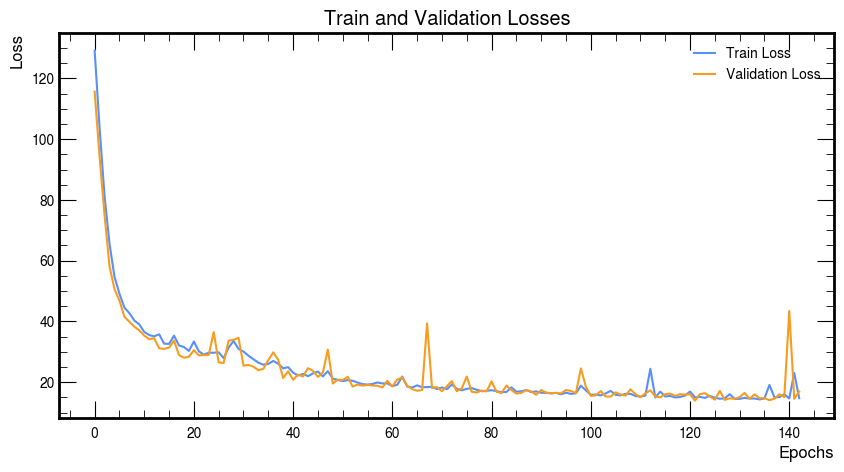

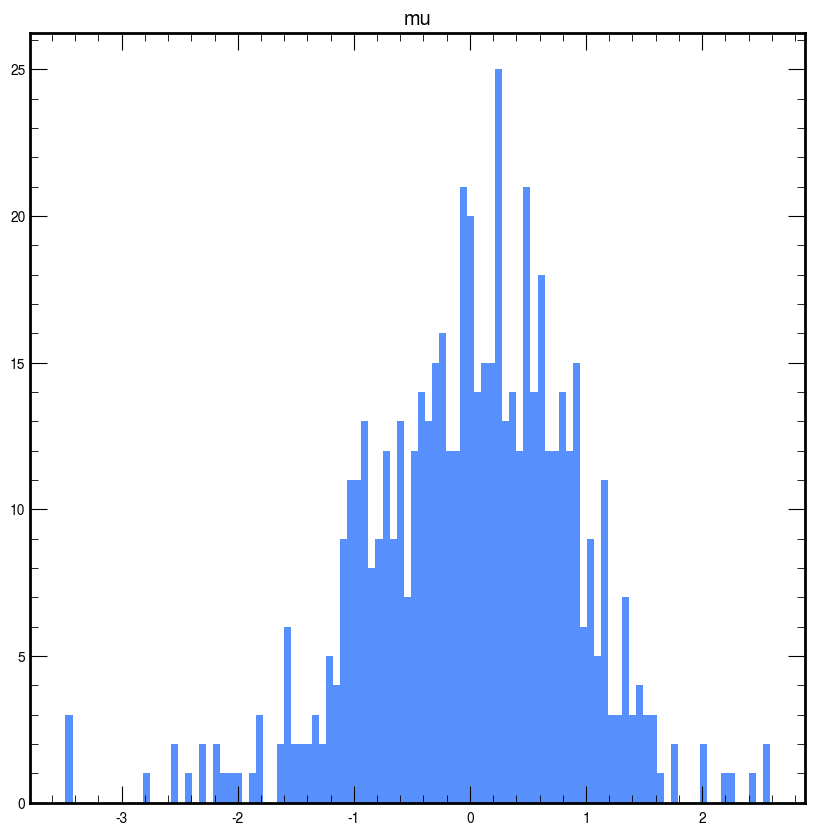

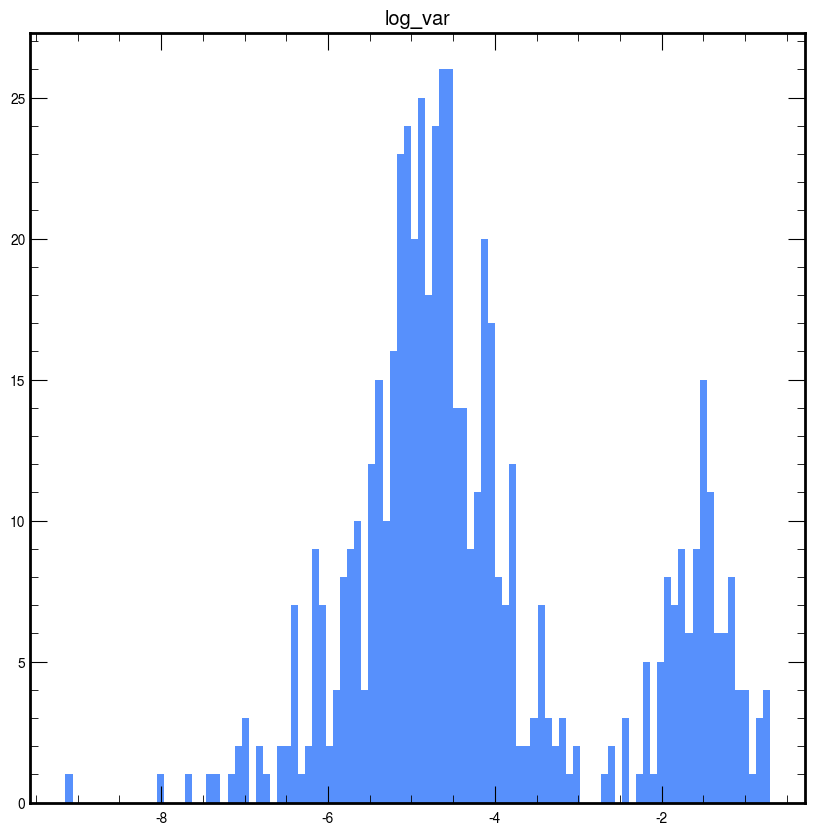

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses[2:], label='Train Loss')
plt.plot(val_losses[2:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.show()

plt.hist(mu.flatten().cpu().numpy(), bins=100)
plt.title('mu')
plt.show()
plt.hist(log_var.flatten().cpu().numpy(), bins=100)
plt.title('log_var')
plt.show()

dim 0: KL= 0.544 | z0 mean=+0.078 std=0.663 | KS vs N(0,1)=0.122
dim 1: KL= 2.362 | z0 mean=-0.030 std=0.878 | KS vs N(0,1)=0.048
dim 2: KL= 2.714 | z0 mean=-0.099 std=1.043 | KS vs N(0,1)=0.044
dim 3: KL= 2.413 | z0 mean=-0.198 std=0.901 | KS vs N(0,1)=0.089
dim 4: KL= 2.635 | z0 mean=-0.084 std=0.995 | KS vs N(0,1)=0.056
dim 5: KL= 2.225 | z0 mean=+0.227 std=0.835 | KS vs N(0,1)=0.141
dim 6: KL= 2.821 | z0 mean=-0.008 std=0.978 | KS vs N(0,1)=0.024
dim 7: KL= 2.147 | z0 mean=-0.165 std=0.899 | KS vs N(0,1)=0.074
dim 8: KL= 0.854 | z0 mean=+0.129 std=0.827 | KS vs N(0,1)=0.085


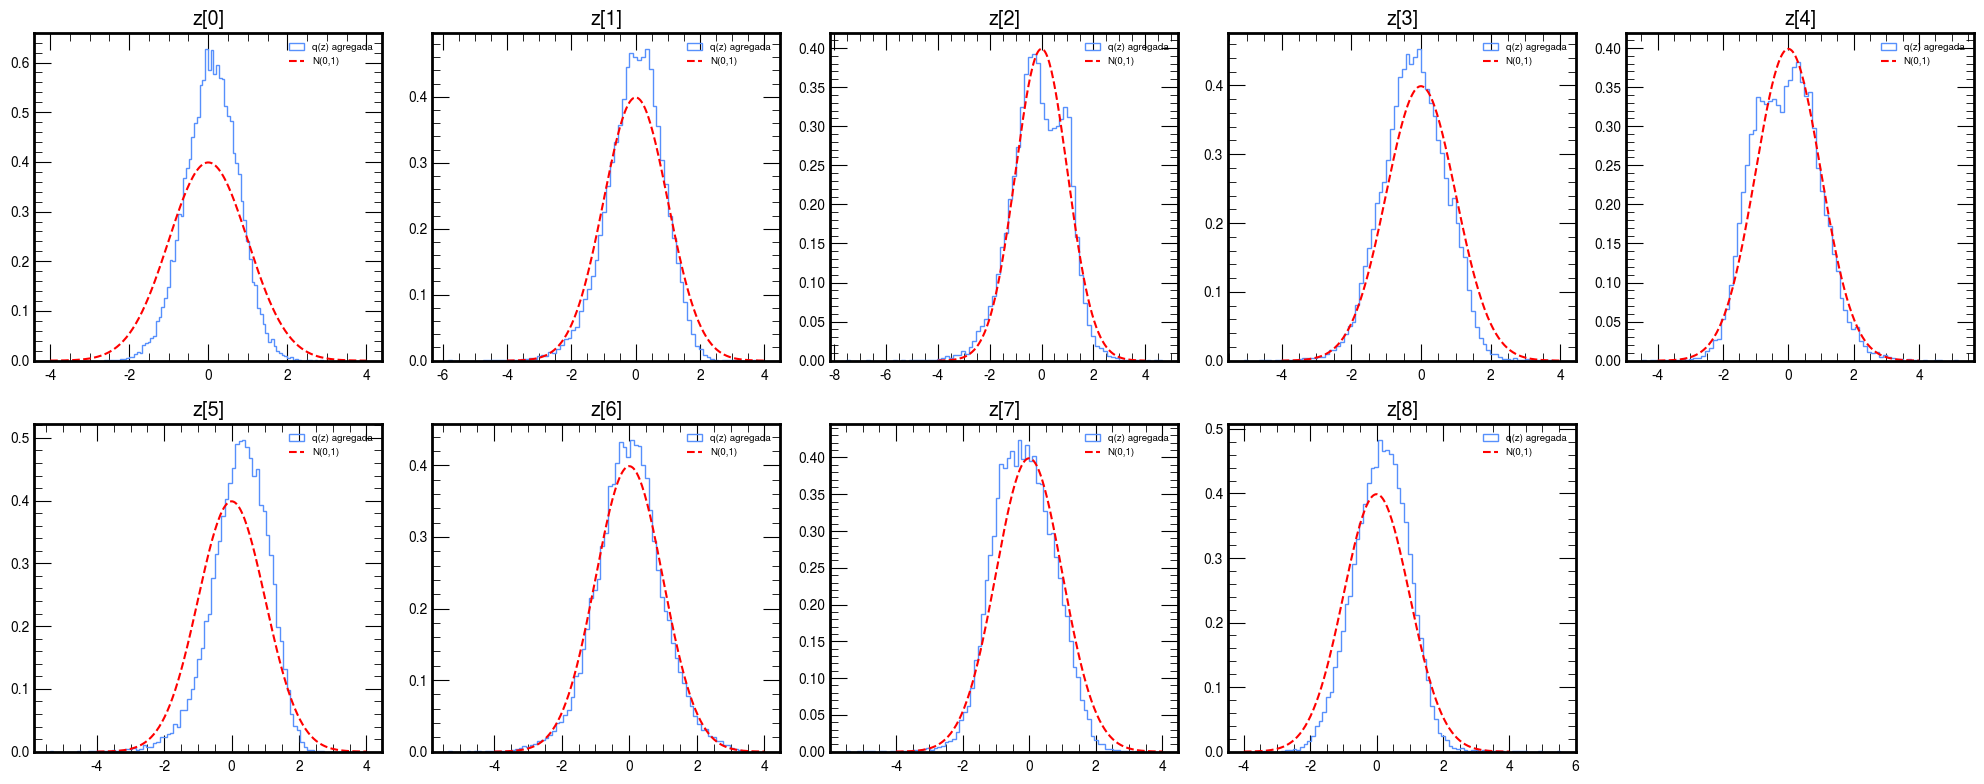

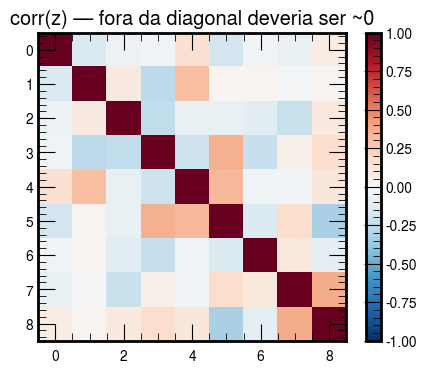

In [13]:
import numpy as np, matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from torch.utils.data import DataLoader

model.eval()
mus, lvs, z0s, zps = [], [], [], []
with torch.no_grad():
    for batch in DataLoader(x_train, batch_size=512, shuffle=False):
        batch = batch.to(device)
        mu, log_var = model.encoder(batch)
        z = model.sampling(mu, log_var)
        z0 = z.clone()                     # pré-flow
        for flow in model.flows:
            z, _ = flow(z)                 # pós-flow
        mus.append(mu.cpu()); lvs.append(log_var.cpu())
        z0s.append(z0.cpu()); zps.append(z.cpu())

mu_all  = torch.cat(mus).numpy()
lv_all  = torch.cat(lvs).numpy()
z0_all  = torch.cat(z0s).numpy()           # q(z) agregada, pré-flow  → deveria ~ N(0,1)
zp_all  = torch.cat(zps).numpy()           # o que o decoder vê na reconstrução
zdim = mu_all.shape[1]

# 1) KL por dimensão: detecta dimensões colapsadas (posterior collapse)
kl = 0.5 * (mu_all**2 + np.exp(lv_all) - 1 - lv_all)
kl = kl.mean(axis=0)
for j in range(zdim):
    print(f"dim {j}: KL={kl[j]:6.3f} | z0 mean={z0_all[:,j].mean():+.3f} std={z0_all[:,j].std():.3f} "
          f"| KS vs N(0,1)={stats.kstest(z0_all[:,j],'norm').statistic:.3f}")

# 2) histograma por dimensão do z pré-flow vs N(0,1)
xs = np.linspace(-4, 4, 200)
ncol = (zdim + 1) // 2
fig, axes = plt.subplots(2, ncol, figsize=(4*ncol, 8))
for j in range(zdim):
    ax = axes.flat[j]
    ax.hist(z0_all[:, j], bins=80, density=True, histtype='step', label='q(z) agregada')
    ax.plot(xs, norm.pdf(xs), 'r--', label='N(0,1)')
    ax.set_title(f'z[{j}]'); ax.legend(fontsize=7)
for k in range(zdim, len(axes.flat)): axes.flat[k].axis('off')
plt.tight_layout(); plt.show()

# 3) matriz de correlação do latente (N(0,I) é diagonal)
plt.figure(figsize=(5,4))
plt.imshow(np.corrcoef(z0_all.T), vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(); plt.title('corr(z) — fora da diagonal deveria ser ~0'); plt.show()

Amostra do VAE tentando reproduzir o dataset de treino (dados normalizados)

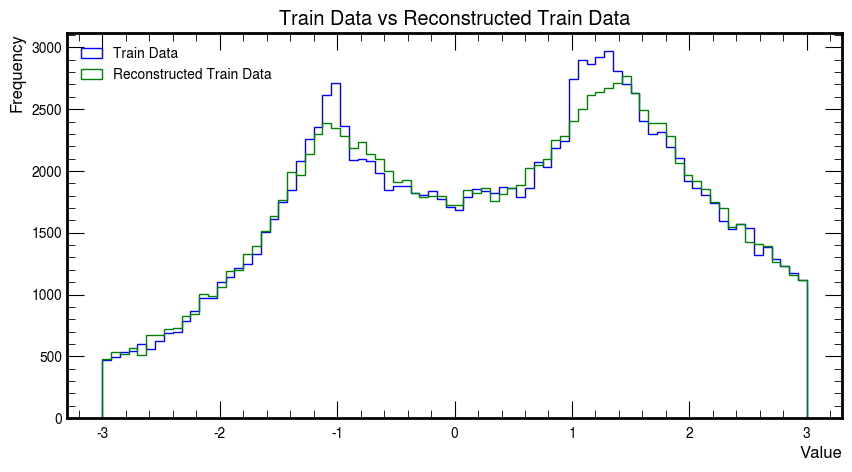

In [14]:
model.eval()
with torch.no_grad():
    recon_train, _, _, _ = model(x_train.float())


plt.figure(figsize=(10, 5))
plt.hist(denormalize(x_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Train Data')
plt.hist(denormalize(recon_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando reproduzir o dataset de teste (dados normalizados)

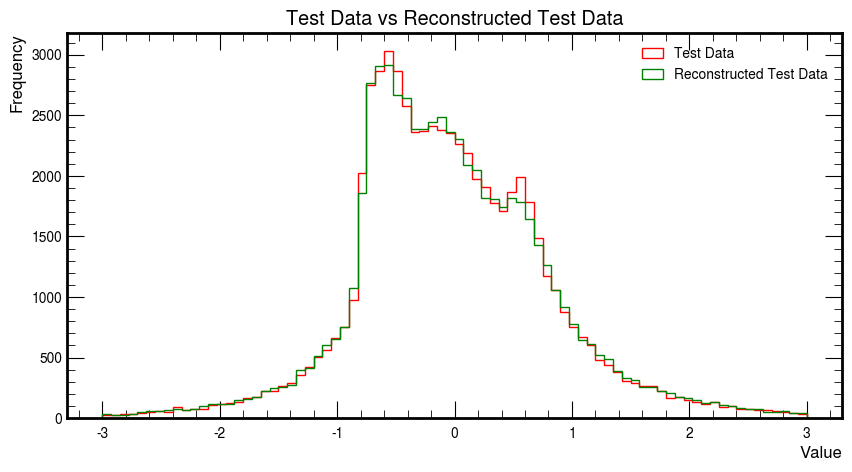

In [15]:
with torch.no_grad():
    recon_test, _, _, _ = model(x_test.float())

plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando gerar novos dados que seguem a distribuição do input (dados normalizados)

In [16]:
import torch, torch.nn as nn, numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

model.eval()
z_post = []
with torch.no_grad():
    for batch in DataLoader(x_train, batch_size=512, shuffle=False):
        batch = batch.to(device)
        mu, log_var = model.encoder(batch)
        z = model.sampling(mu, log_var)
        for fl in model.flows:
            z, _ = fl(z)
        z_post.append(z.cpu())
z_post = torch.cat(z_post).numpy()

scaler = StandardScaler().fit(z_post)
z_std  = torch.tensor(scaler.transform(z_post), dtype=torch.float32)
D = z_std.shape[1]

class Coupling(nn.Module):
    def __init__(self, dim, mask, hidden=128):
        super().__init__()
        self.register_buffer('mask', mask)
        self.net = nn.Sequential(nn.Linear(dim, hidden), nn.LeakyReLU(),
                                 nn.Linear(hidden, hidden), nn.LeakyReLU(),
                                 nn.Linear(hidden, 2*dim))
    def _st(self, xm):
        s, t = self.net(xm).chunk(2, dim=1)
        return torch.tanh(s) * (1 - self.mask), t * (1 - self.mask)
    def forward(self, x):                      # x -> base (densidade)
        xm = x * self.mask; s, t = self._st(xm)
        return xm + (1 - self.mask) * (x * torch.exp(s) + t), s.sum(dim=1)
    def inverse(self, z):                      # base -> x (amostragem)
        zm = z * self.mask; s, t = self._st(zm)
        return zm + (1 - self.mask) * ((z - t) * torch.exp(-s))

class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=8, hidden=128):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            m = (torch.arange(dim) % 2).float()
            self.layers.append(Coupling(dim, m if i % 2 == 0 else 1 - m, hidden))
    def log_prob(self, x):
        ld = 0
        for L in self.layers: x, d = L(x); ld = ld + d
        return (-0.5 * (x**2 + np.log(2*np.pi)).sum(1)) + ld
    def sample(self, n):
        z = torch.randn(n, self.layers[0].mask.numel(), device=self.layers[0].mask.device)
        for L in reversed(self.layers): z = L.inverse(z)
        return z

flow_density = RealNVP(D, n_layers=8, hidden=128).to(device)
opt = torch.optim.Adam(flow_density.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(z_std), batch_size=256, shuffle=True)
for epoch in range(200):
    tot = 0.0
    for (zb,) in loader:
        zb = zb.to(device)
        loss = -flow_density.log_prob(zb).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(zb)
    if (epoch + 1) % 40 == 0:
        print(f"epoch {epoch+1}: NLL={tot/len(z_std):.3f}")

mean_t = torch.tensor(scaler.mean_,  dtype=torch.float32, device=device)
std_t  = torch.tensor(scaler.scale_, dtype=torch.float32, device=device)
def sample_generated(n):
    flow_density.eval()
    with torch.no_grad():
        z_s = flow_density.sample(n) * std_t + mean_t
        return model.decoder(z_s)

epoch 40: NLL=7.247
epoch 80: NLL=6.914
epoch 120: NLL=6.704
epoch 160: NLL=6.550
epoch 200: NLL=6.409


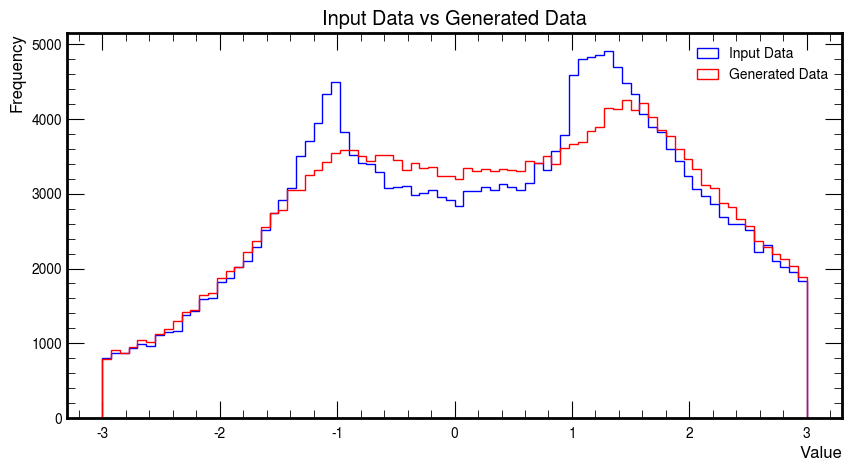

In [17]:
#with torch.no_grad():
    #z = torch.randn(tensor_data.size(0), best_params['latent_dim']).to(device)
    #generated_data = model.decoder(z)

with torch.no_grad():
    
    generated_data = sample_generated(tensor_data.size(0))

plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [18]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().numpy().flatten(), recon_train.cpu().numpy().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().numpy().flatten(), recon_test.cpu().numpy().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.0071666666666666545, p-value=0.00010379905076156647
KS test for Test vs. Reconstructed Test: statistic=0.007078125000000046, p-value=0.08061736825312282
KS test for Input vs. Generated: statistic=0.011409375, p-value=1.6084917613119776e-18


Abaixo, iremos desnormalizar os dados para gerar plots com a distribuição original, retomando a problemática da distribuição dos momentos tranversais dos píons e dos kaons.

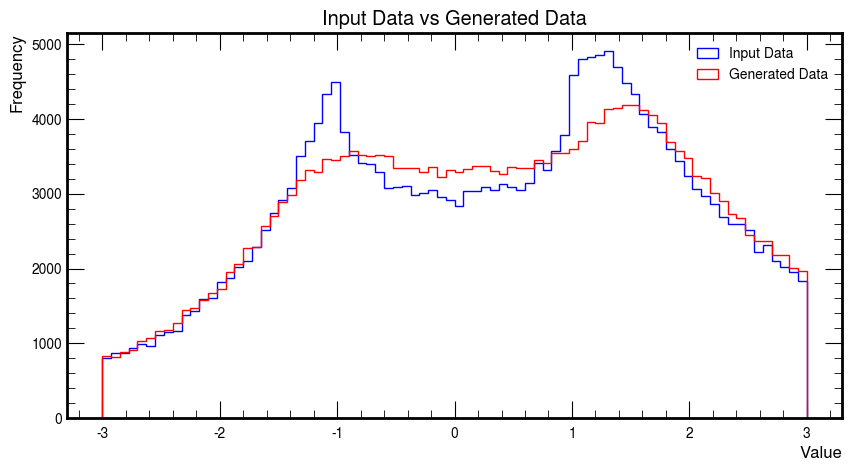

In [19]:
with torch.no_grad():

    generated_data = sample_generated(tensor_data.size(0))

plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de treino (dados desnormalizados)

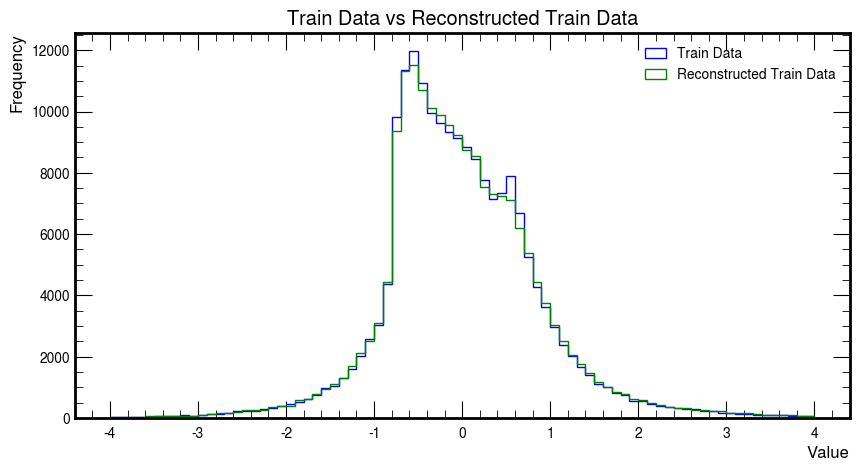

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(x_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Train Data')
plt.hist(recon_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de teste (dados desnormalizados)

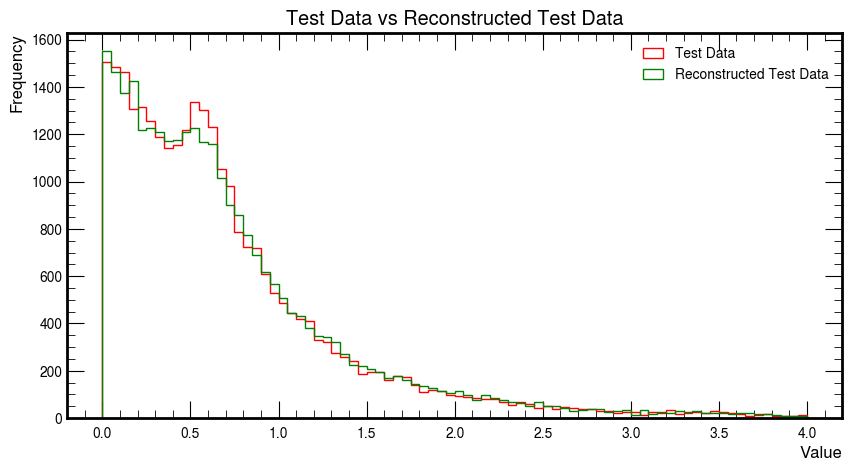

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [22]:
import numpy as np, scipy.stats as stats
from scipy.stats import wasserstein_distance
from torch.utils.data import DataLoader

cols = ['px1','px2','py1','py2','pz1','pz2','E1','E2']

model.eval()
with torch.no_grad():
    recon_test, _, _, _ = model(x_test.float())

xt = x_test.cpu().numpy()      # normalizado
rt = recon_test.cpu().numpy()
resid = rt - xt                # resíduo por evento, em unidades do σ de treino

print(f"{'var':>4} | {'bias':>7} | {'RMS':>6} | {'R2':>6} | {'KS':>6} | {'W':>6}")
for i, name in enumerate(cols):
    bias = resid[:, i].mean()
    rms  = resid[:, i].std()
    r2   = 1 - resid[:, i].var() / xt[:, i].var()      # qualidade evento-a-evento
    ks   = stats.ks_2samp(xt[:, i], rt[:, i]).statistic # qualidade da marginal
    w    = wasserstein_distance(xt[:, i], rt[:, i])
    print(f"{name:>4} | {bias:+7.3f} | {rms:6.3f} | {r2:6.3f} | {ks:6.3f} | {w:6.3f}")

 var |    bias |    RMS |     R2 |     KS |      W
 px1 |  +0.126 |  0.103 |  0.990 |  0.066 |  0.127
 px2 |  -0.053 |  0.103 |  0.989 |  0.037 |  0.053
 py1 |  -0.055 |  0.087 |  0.993 |  0.036 |  0.055
 py2 |  -0.002 |  0.088 |  0.992 |  0.011 |  0.012
 pz1 |  +0.016 |  0.093 |  0.992 |  0.009 |  0.018
 pz2 |  -0.010 |  0.100 |  0.990 |  0.020 |  0.022
  E1 |  +0.016 |  0.117 |  0.987 |  0.019 |  0.021
  E2 |  +0.012 |  0.107 |  0.989 |  0.014 |  0.018


Amostra do VAE tentando gerar novos dados que seguem a mesma distribuição do input (dados desnormalizados)

In [23]:
# PLOTS FUNCTION

def subplot_trk(data, generated, trk):
    if trk == "trk1":
        id_list = [0, 2, 4, 6]
        name_list = ["Kaons x component momentum (Px)", "Kaons y component momentum (Py)", "Kaons z component momentum (Pz)", "Kaons energy (E)"]
    if trk == "trk2":
        id_list = [1, 3, 5, 7]
        name_list = ["Pions x component momentum (Px)", "Pions y component momentum (Py)", "Pions z component momentum (Pz)", "Pions energy (E)"]
    if trk == "both":
        data_tensor = torch.zeros([2*data.size()[0], 4])
        gen_tensor = torch.zeros([2*data.size()[0], 4])
        data_tensor[:, 0], gen_tensor[:, 0] = data[:, :2].flatten(), generated[:, :2].flatten()
        data_tensor[:, 1], gen_tensor[:, 1] = data[:, 2:4].flatten(), generated[:, 2:4].flatten()
        data_tensor[:, 2], gen_tensor[:, 2] = data[:, 4:6].flatten(), generated[:, 4:6].flatten()
        data_tensor[:, 3], gen_tensor[:, 3] = data[:, 6:8].flatten(), generated[:, 6:8].flatten()
        data, generated = data_tensor, gen_tensor
        id_list = [0, 1, 2, 3]
        name_list = ["Px1+Px2", "Py1+Py2", "Pz1+Pz2", "E1+E2"]
        
    range_list = [[-5, 5], [-5, 5], [-5, 5], [0, 20]]
    
    plt.figure(figsize=(10,10))
    for i in range(len(id_list)):
        plt.subplot(2, 2, i+1)
        counts_data, bins_data, _ = plt.hist(data[:, id_list[i]].numpy().flatten(), bins=50, range=range_list[i], histtype='step', color='blue', label='Input Data')
        counts_reco, bins_reco, _ = plt.hist(generated[:, id_list[i]].numpy().flatten(), bins=50, range=range_list[i], histtype='step', color='red', label='Generated Data')
        errors_data, errors_reco = np.sqrt(counts_data), np.sqrt(counts_reco)
        bin_centers = 0.5*(bins_data[:-1] + bins_data[1:])
        hep.histplot(counts_data, bins_data, yerr=True, fmt='none', histtype='errorbar', color='blue')
        hep.histplot(counts_reco, bins_reco, yerr=True, fmt='none', histtype='errorbar', color='red')
        #plt.errorbar(bin_centers, counts_data, yerr=errors_data, fmt='none', ecolor='blue', alpha=1.0)
        #plt.errorbar(bin_centers, counts_reco, yerr=errors_reco, fmt='none', ecolor='red', alpha=1.0)
        plt.title(f'{name_list[i]}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()

    return plt.show()

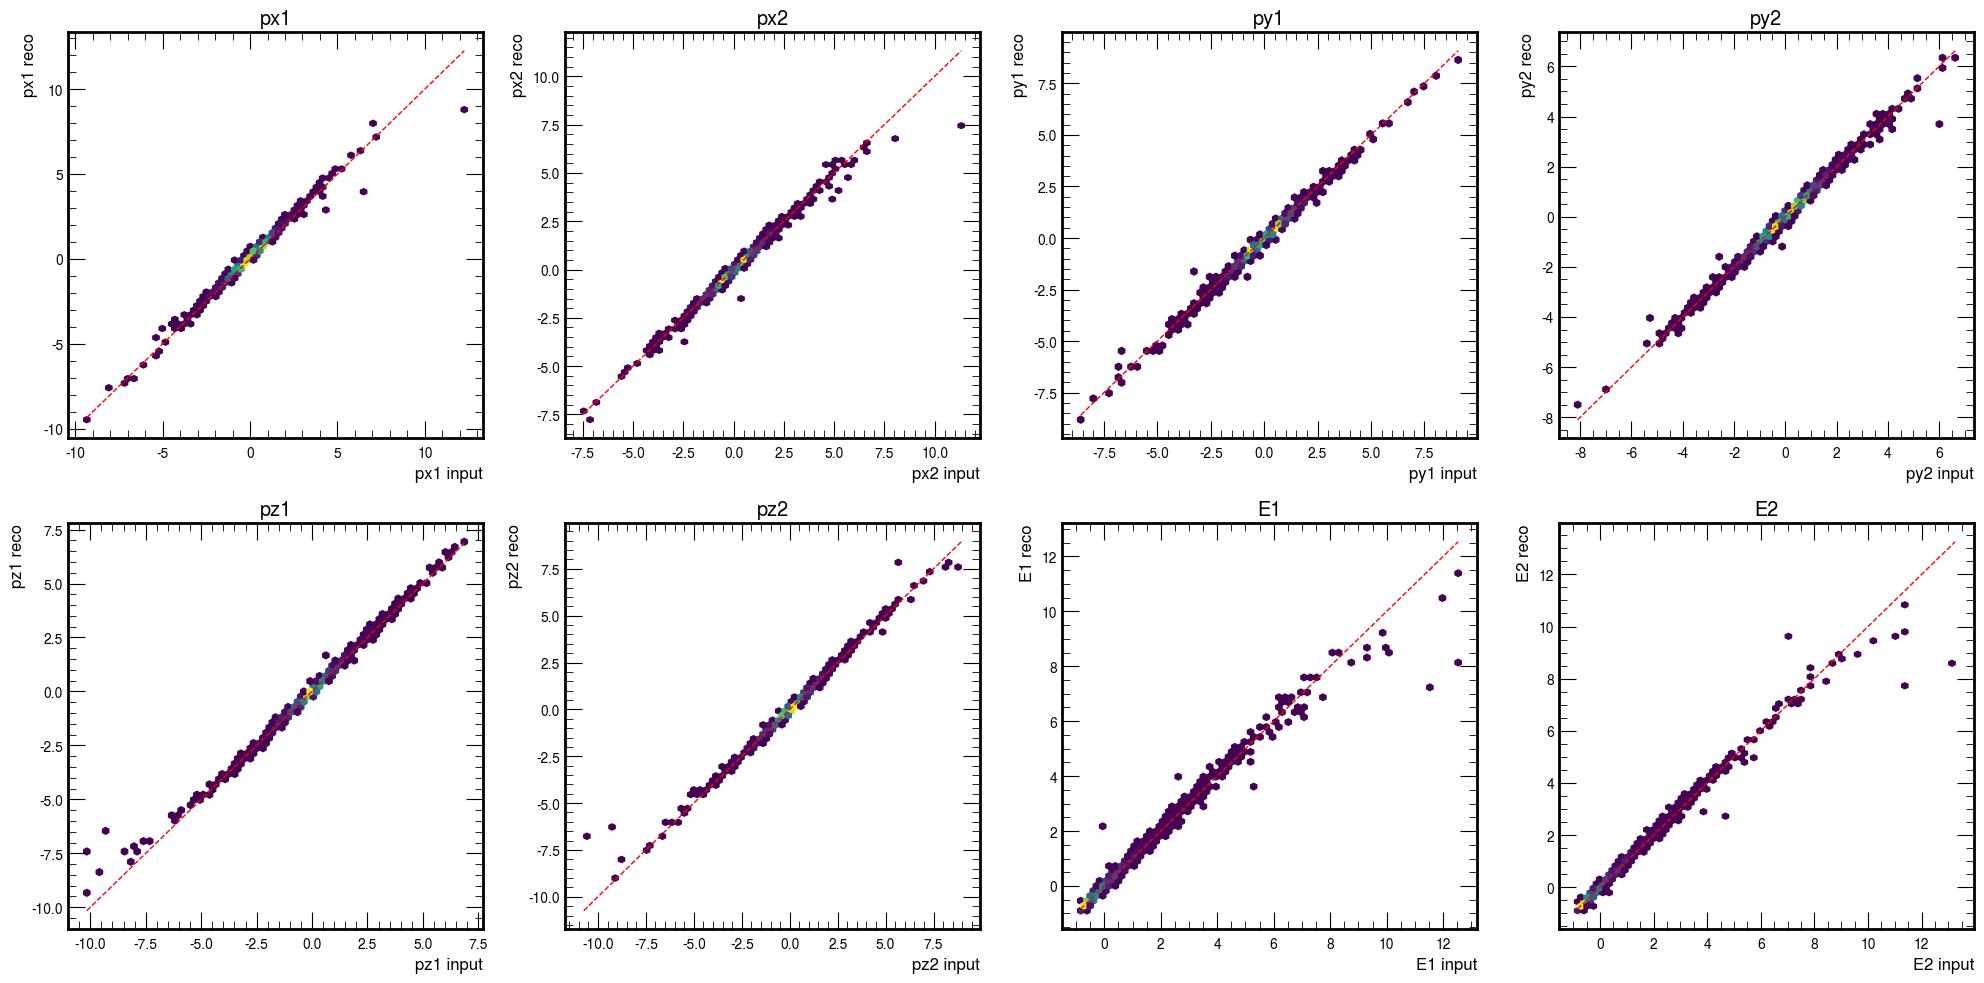

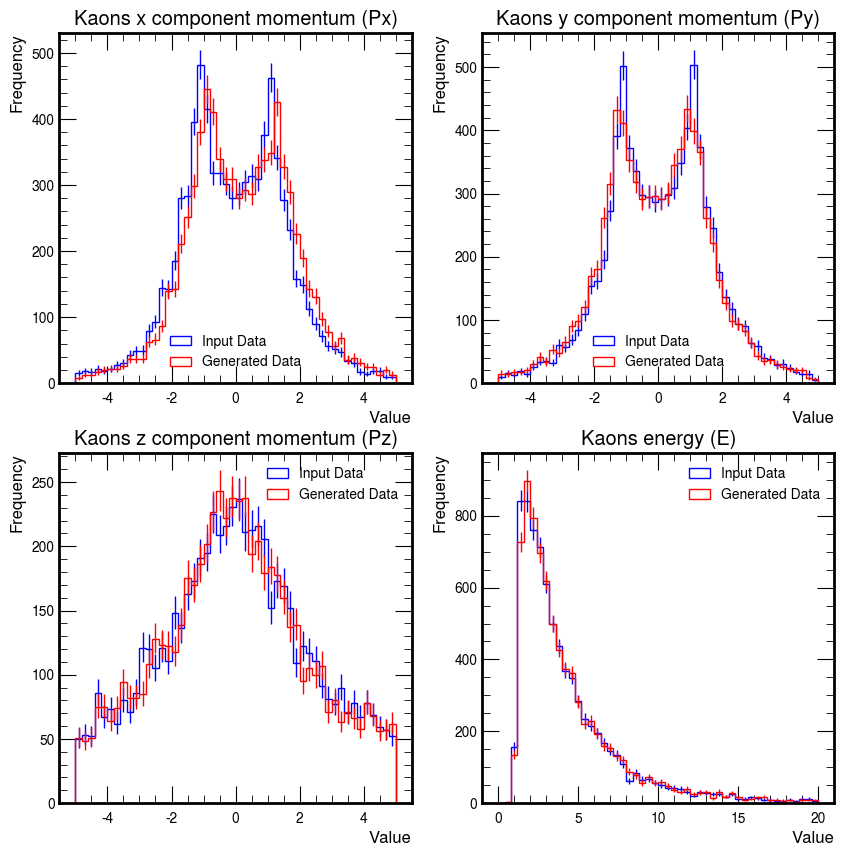

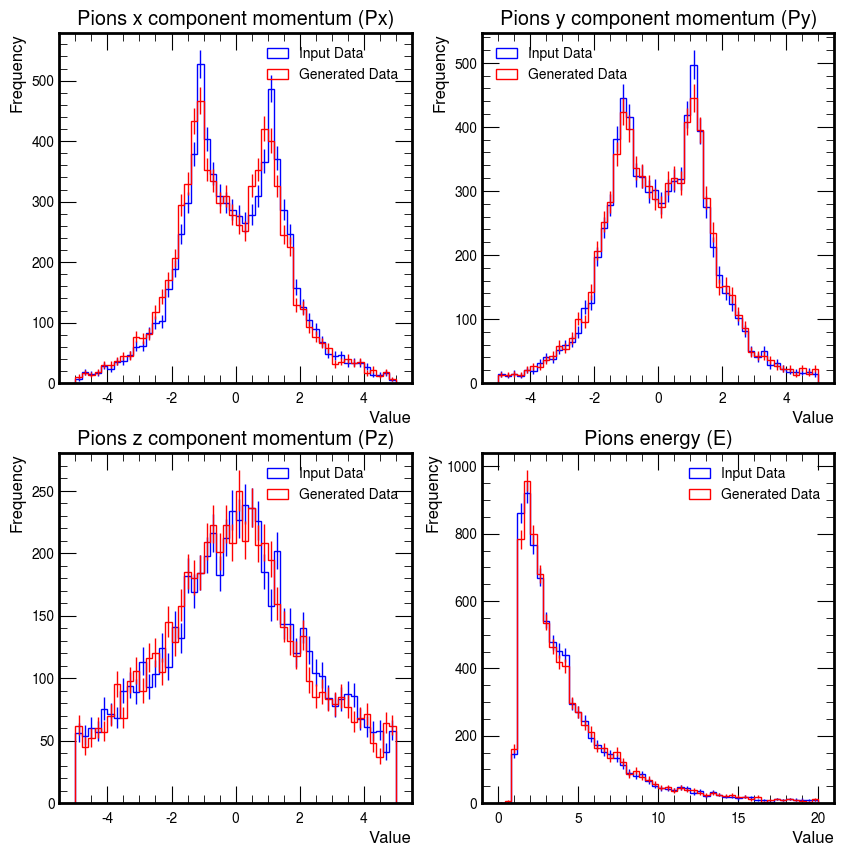

In [24]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, name in enumerate(cols):
    ax = axes.flat[i]
    ax.hexbin(xt[:, i], rt[:, i], gridsize=60, mincnt=1)
    lims = [xt[:, i].min(), xt[:, i].max()]
    ax.plot(lims, lims, 'r--', lw=1)        # onde reco = input
    ax.set_xlabel(f'{name} input'); ax.set_ylabel(f'{name} reco'); ax.set_title(name)
plt.tight_layout(); plt.show()

# e a versão por componente reaproveitando sua própria função:
subplot_trk(denormalize(x_test).cpu(), denormalize(recon_test).cpu(), "trk1")
subplot_trk(denormalize(x_test).cpu(), denormalize(recon_test).cpu(), "trk2")

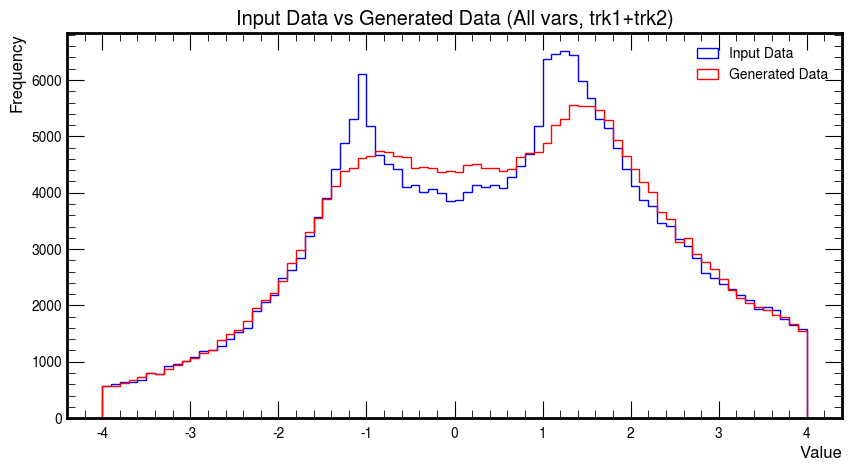

torch.Size([40000, 8])


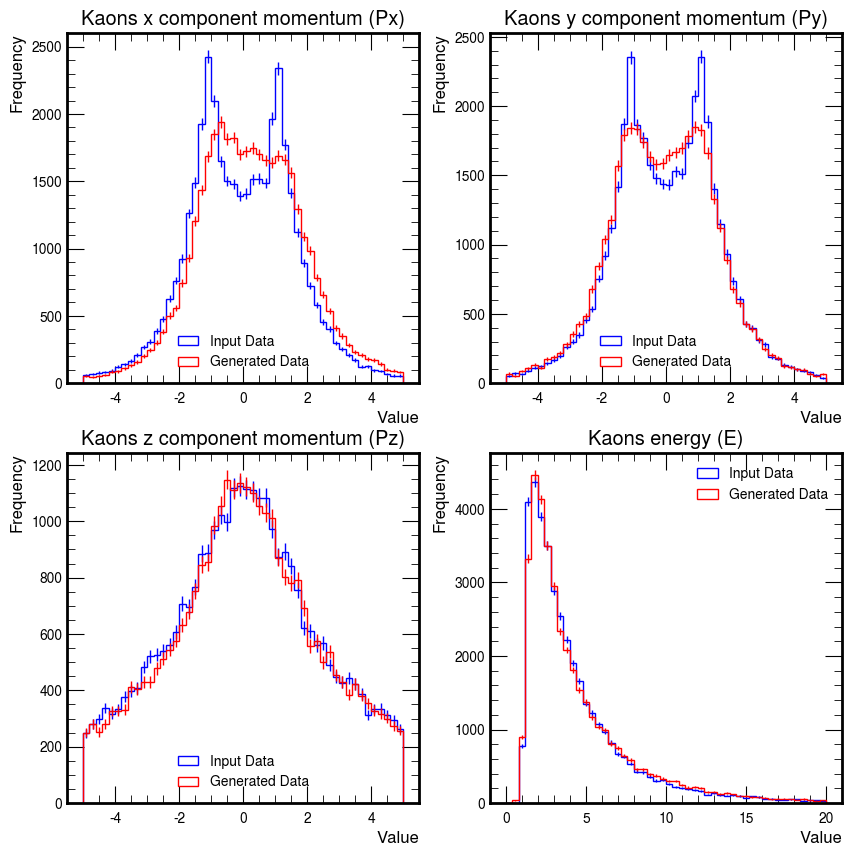

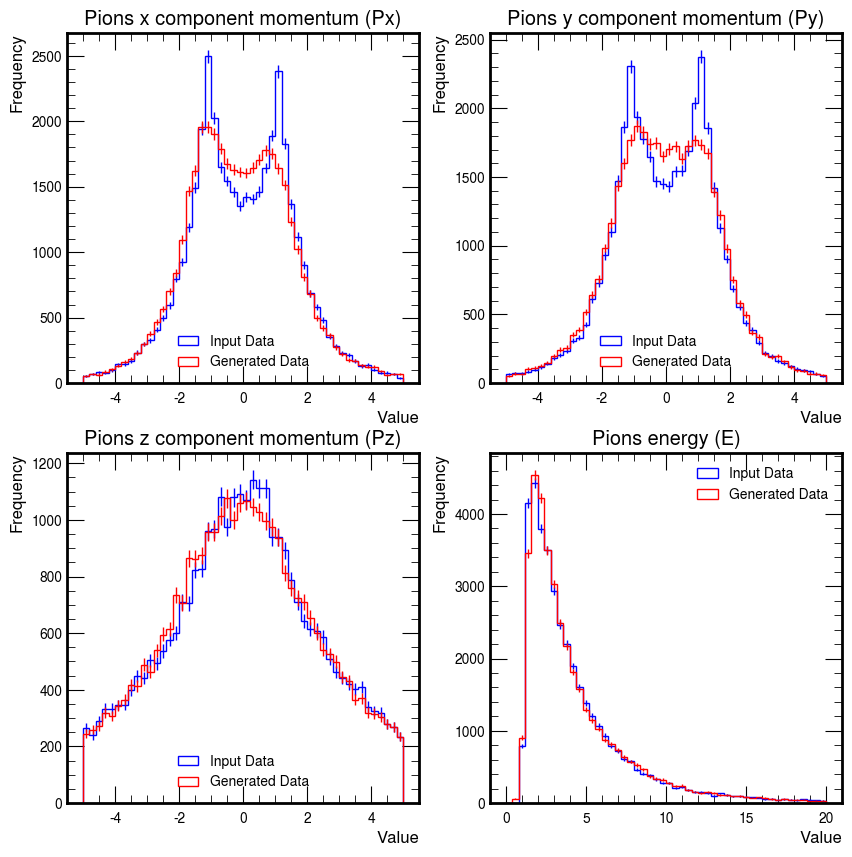

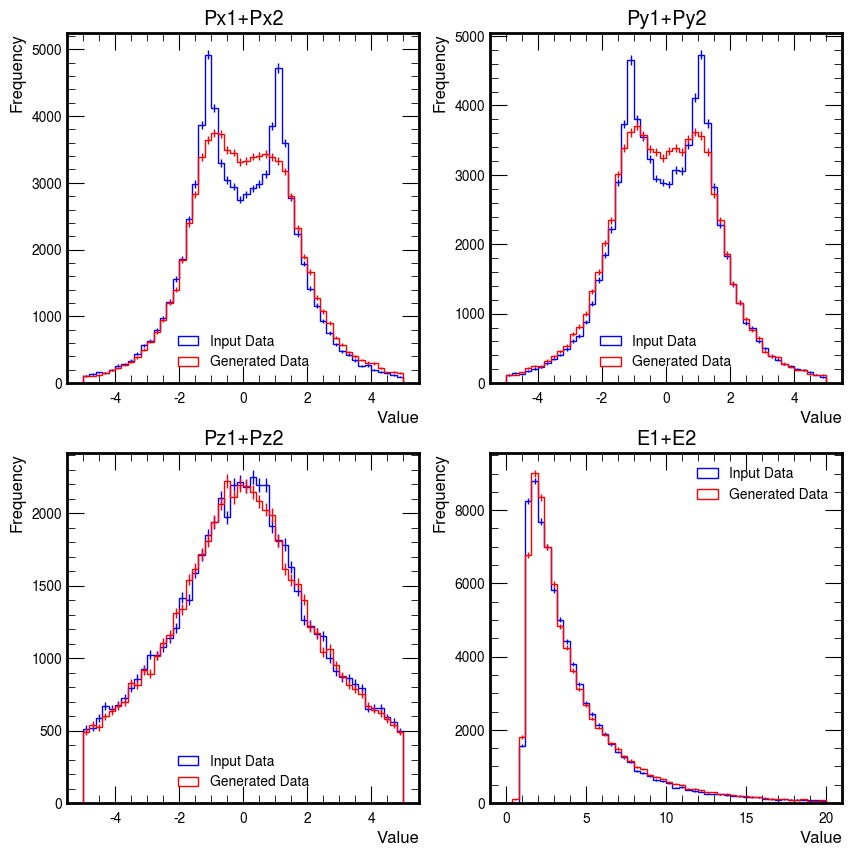

In [25]:
plt.figure(figsize=(10, 5))
plt.hist(tensor_data_denormalized.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(denormalize(generated_data).cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(tensor_data.size())
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "trk1")
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "trk2")
subplot_trk(tensor_data_denormalized.cpu(), denormalize(generated_data).cpu(), "both")

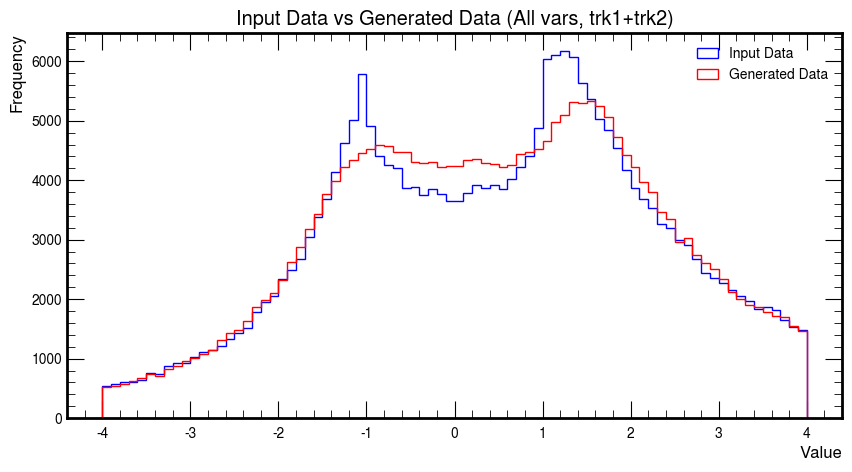

torch.Size([37744, 8])


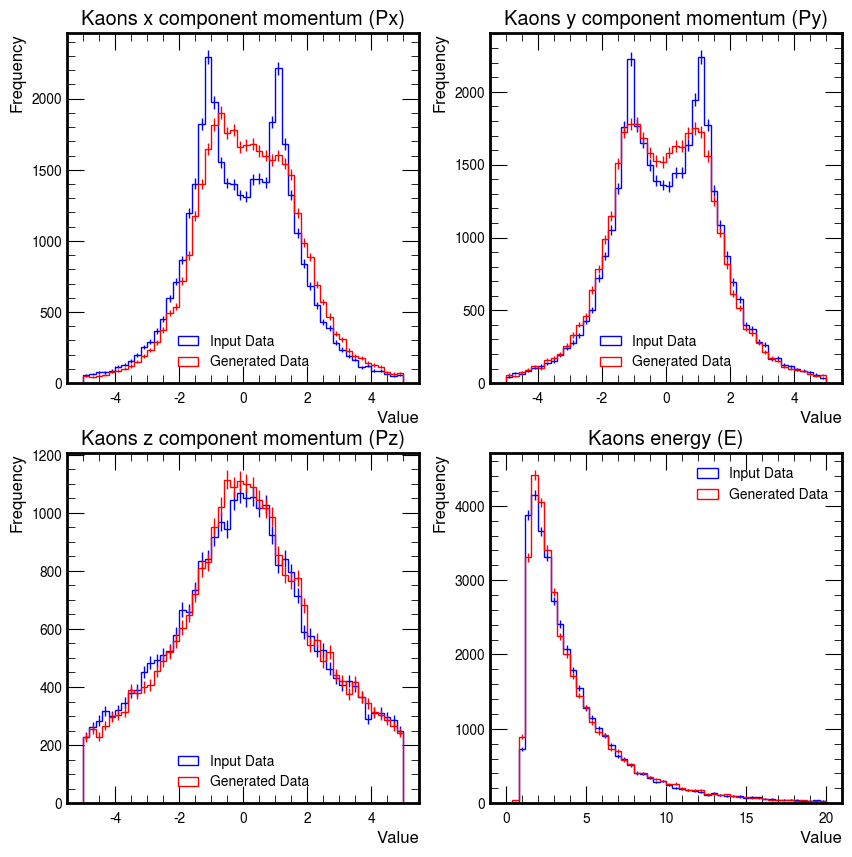

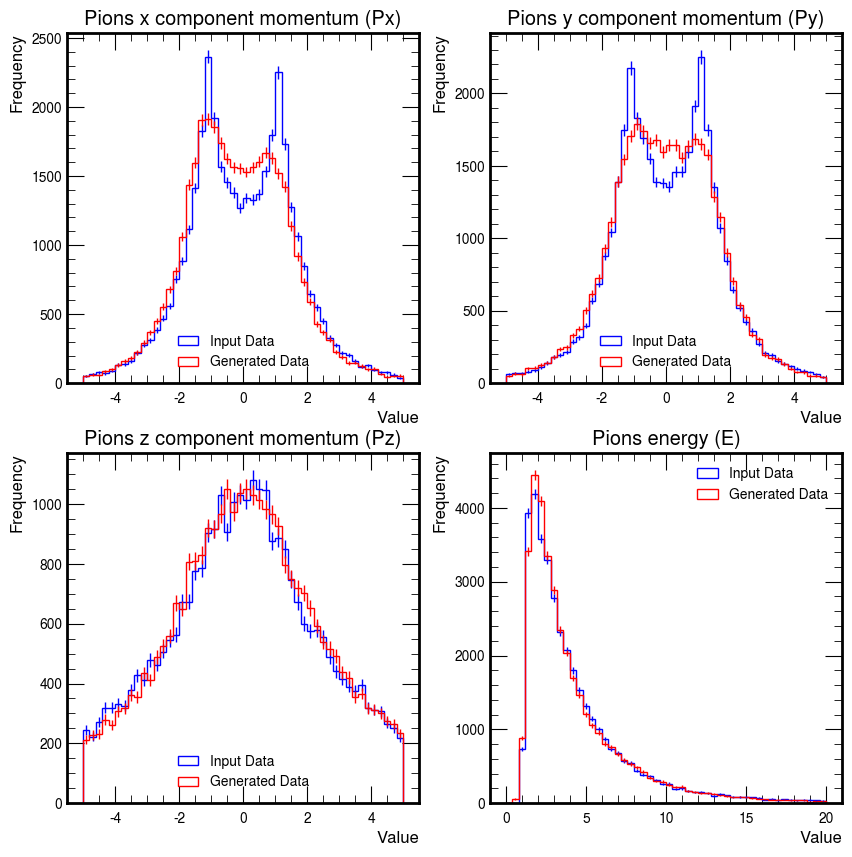

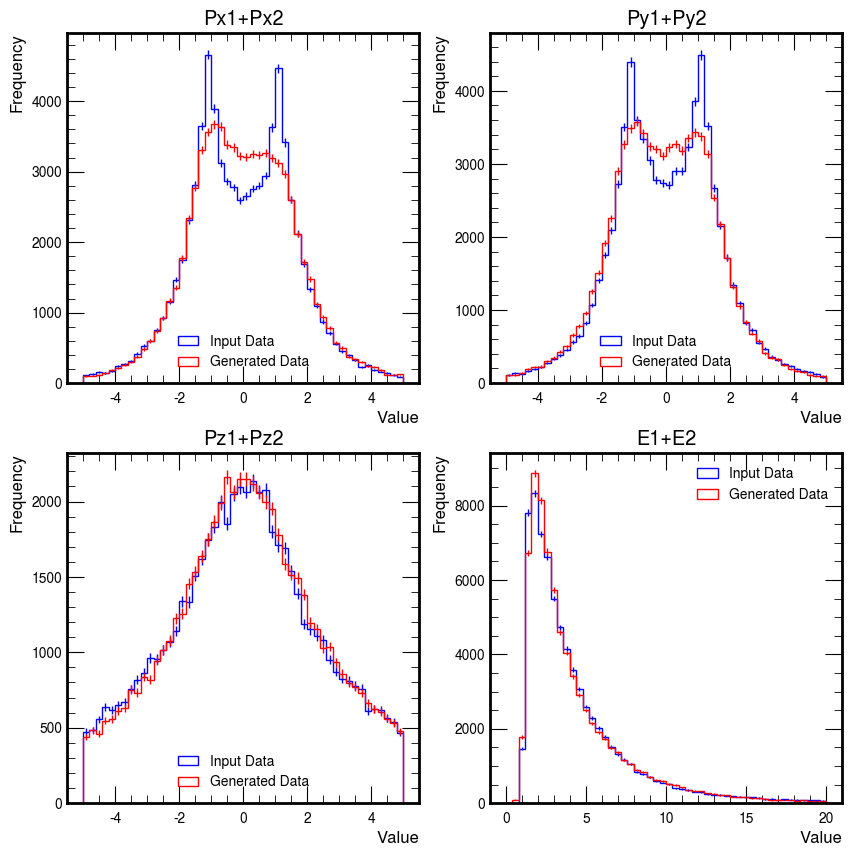

In [26]:
generated_data_denormalized = denormalize(generated_data)

generated_px = generated_data_denormalized[:, 0] + generated_data_denormalized[:, 1]
generated_py = generated_data_denormalized[:, 2] + generated_data_denormalized[:, 3]
generated_pz = generated_data_denormalized[:, 4] + generated_data_denormalized[:, 5]
generated_E = generated_data_denormalized[:, 6] + generated_data_denormalized[:, 7]


mass2 = generated_E**2 - generated_px**2 - generated_py**2 - generated_pz**2
mass_mask = mass2 > 0

energies_mask = ((generated_data_denormalized[:, 6] > 0) & (generated_data_denormalized[:, 7] > 0))
physical_mask = (mass_mask & energies_mask)
filtered_generated_data = generated_data_denormalized[physical_mask]
filtered_tensor_data_denormalized = tensor_data_denormalized[physical_mask]

plt.figure(figsize=(10, 5))
plt.hist(filtered_tensor_data_denormalized.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(filtered_generated_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(filtered_tensor_data_denormalized.size())
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "trk1")
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "trk2")
subplot_trk(filtered_tensor_data_denormalized.cpu(), filtered_generated_data.cpu(), "both")

Abaixo, é rodado um teste de Kolmogorov-Smirnov para analisar a proximidade dos dois hitogramas em cada gráfico (apenas para as distribuições desnormalizadas). Uma das métricas de interesse é o p-valor.

P-Valor Significativo: um p-valor abaixo de 0.05 é frequentemente considerado significativo, o que indica que a hipótese nula (de que as distribuições são iguais) pode ser rejeitada.

P-Valor Não Significativo: Um p-valor acima de 0.05 geralmente sugere que não há evidência suficiente para rejeitar a hipótese nula. Valores como 0.10, 0.15, ou mais altos são interpretados como indicando uma falta de diferença significativa entre as distribuições.

P-Valor > 0.05: Indica que não há uma diferença significativa entre as distribuições comparadas. Esse é um bom sinal, sugerindo que as distribuições dos dados gerados ou reconstruídos são semelhantes aos dados reais.

P-Valor > 0.10 ou 0.15: Indica uma forte semelhança entre as distribuições, o que é ótimo.

In [27]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().flatten(), recon_train.cpu().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().flatten(), recon_test.cpu().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().flatten(), generated_data.cpu().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.0071666666666666545, p-value=0.00010379905076156647
KS test for Test vs. Reconstructed Test: statistic=0.00701562499999997, p-value=0.0852953173541302
KS test for Input vs. Generated: statistic=0.011668750000000006, p-value=2.368161711662105e-19


In [28]:
print(mass_func(generated_data_denormalized).mean())
print(torch.sqrt(torch.clamp(mass_func(generated_data_denormalized).mean(), min=0.0)))  #  1.8648 

tensor(4.0771, device='cuda:0')
tensor(2.0192, device='cuda:0')


In [29]:
wasserstein_distance(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

np.float64(0.021987395188963168)

In [30]:
# Comparação correta — test set vs gerado condicionado no test set
input_generated_ks = stats.ks_2samp(
    x_test.cpu().numpy().flatten(),
    generated_data.cpu().numpy().flatten()
)

cols = ['px1','px2','py1','py2','pz1','pz2','E1','E2']
for i, name in enumerate(cols):
    w = wasserstein_distance(
        x_test.cpu().numpy()[:, i],
        generated_data.cpu().numpy()[:, i]
    )
    print(f"  {name}: {w:.4f}")

  px1: 0.1473
  px2: 0.0513
  py1: 0.0561
  py2: 0.0320
  pz1: 0.0585
  pz2: 0.0200
  E1: 0.0490
  E2: 0.0179


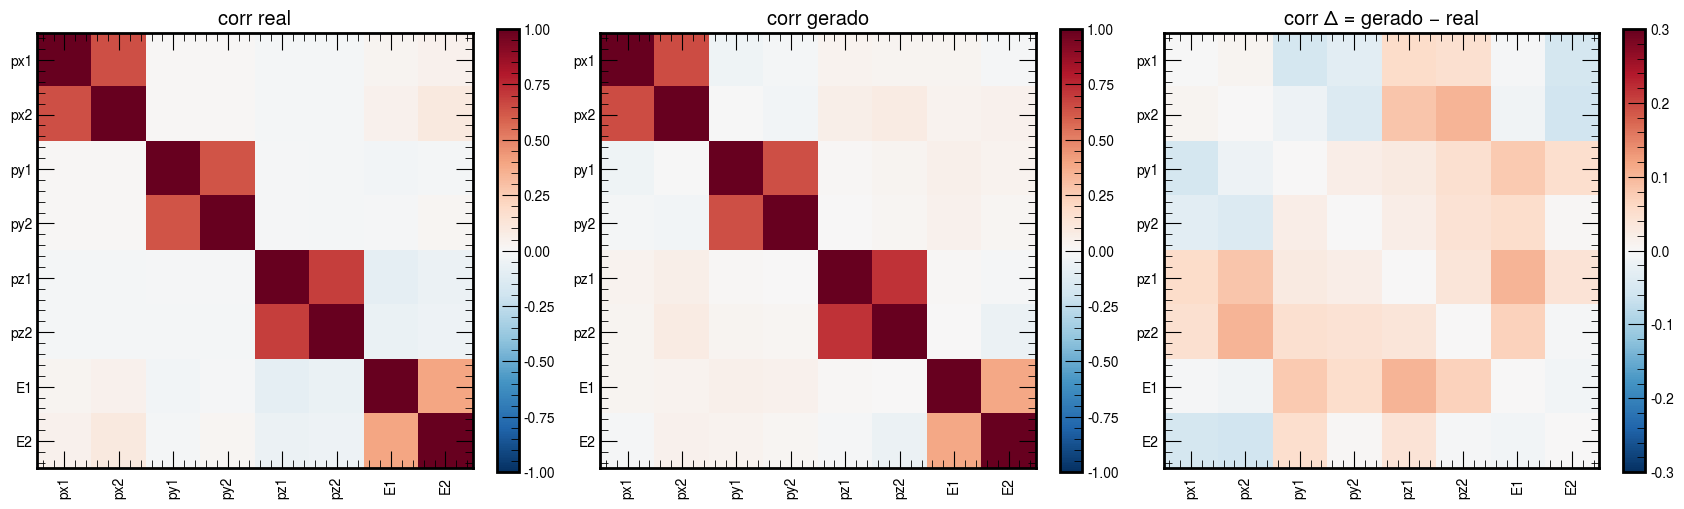

|Δcorr| máx: 0.102 | |Δcorr| médio (off-diag): 0.042


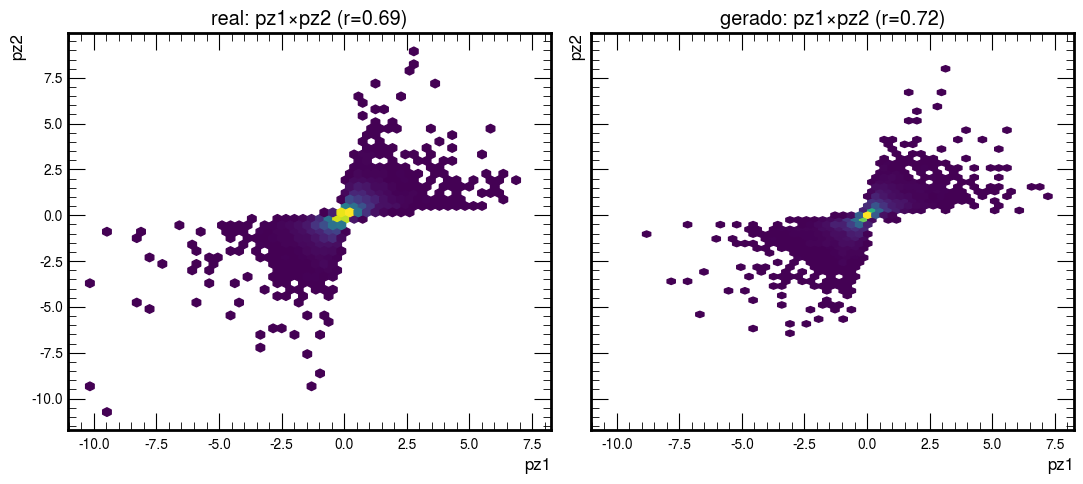

In [31]:
import numpy as np, matplotlib.pyplot as plt
cols = ['px1','px2','py1','py2','pz1','pz2','E1','E2']

model.eval()
real = x_test.cpu().numpy()
gen  = sample_generated(x_test.size(0)).cpu().numpy()

C_real, C_gen = np.corrcoef(real.T), np.corrcoef(gen.T)
dC = C_gen - C_real

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, M, t, lim in [(ax[0], C_real,'real',1),(ax[1], C_gen,'gerado',1),(ax[2], dC,'Δ = gerado − real',0.3)]:
    im = a.imshow(M, vmin=-lim, vmax=lim, cmap='RdBu_r')
    a.set_xticks(range(8)); a.set_xticklabels(cols, rotation=90)
    a.set_yticks(range(8)); a.set_yticklabels(cols)
    a.set_title(f'corr {t}'); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

off = ~np.eye(8, dtype=bool)
print(f"|Δcorr| máx: {np.abs(dC).max():.3f} | |Δcorr| médio (off-diag): {np.abs(dC[off]).mean():.3f}")

# e o par com correlação real mais forte, em 2D
iu = np.triu_indices(8, k=1)
m  = np.argmax(np.abs(C_real[iu])); i, j = iu[0][m], iu[1][m]
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
ax[0].hexbin(real[:,i], real[:,j], gridsize=50, mincnt=1); ax[0].set_title(f'real: {cols[i]}×{cols[j]} (r={C_real[i,j]:.2f})')
ax[1].hexbin(gen[:,i],  gen[:,j],  gridsize=50, mincnt=1); ax[1].set_title(f'gerado: {cols[i]}×{cols[j]} (r={C_gen[i,j]:.2f})')
for a in ax: a.set_xlabel(cols[i]); a.set_ylabel(cols[j])
plt.tight_layout(); plt.show()

AUC real-vs-gerado: 0.705  (0.5 = indistinguível | 1.0 = separa trivialmente)


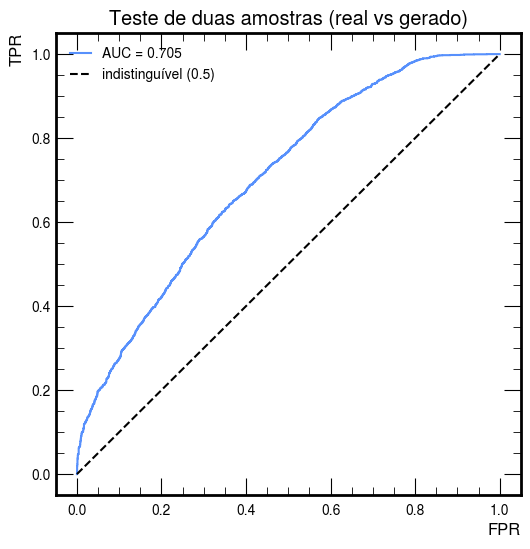

variáveis que mais denunciam o gerado:
   px1: 0.1468
   px2: 0.1039
   pz2: 0.0633
   py1: 0.0589
   pz1: 0.0557
   py2: 0.0305
    E1: 0.0286
    E2: 0.0215


In [32]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np, matplotlib.pyplot as plt
cols = ['px1','px2','py1','py2','pz1','pz2','E1','E2']

model.eval()
real = x_test.cpu().numpy()
gen  = sample_generated(x_test.size(0)).cpu().numpy()

X = np.vstack([real, gen])
y = np.concatenate([np.ones(len(real)), np.zeros(len(gen))])   # 1=real, 0=gerado
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05).fit(Xtr, ytr)
p   = clf.predict_proba(Xte)[:, 1]
auc = roc_auc_score(yte, p)
print(f"AUC real-vs-gerado: {auc:.3f}  (0.5 = indistinguível | 1.0 = separa trivialmente)")

fpr, tpr, _ = roc_curve(yte, p)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--', label='indistinguível (0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Teste de duas amostras (real vs gerado)')
plt.legend(); plt.show()

r = permutation_importance(clf, Xte, yte, scoring='roc_auc', n_repeats=10, random_state=0)
print("variáveis que mais denunciam o gerado:")
for k in np.argsort(r.importances_mean)[::-1]:
    print(f"  {cols[k]:>4}: {r.importances_mean[k]:.4f}")

massa real:        média=1.8676  σ=0.0202
massa reconstruída: média=1.8783  σ=0.9231  (alvo 1.8648)


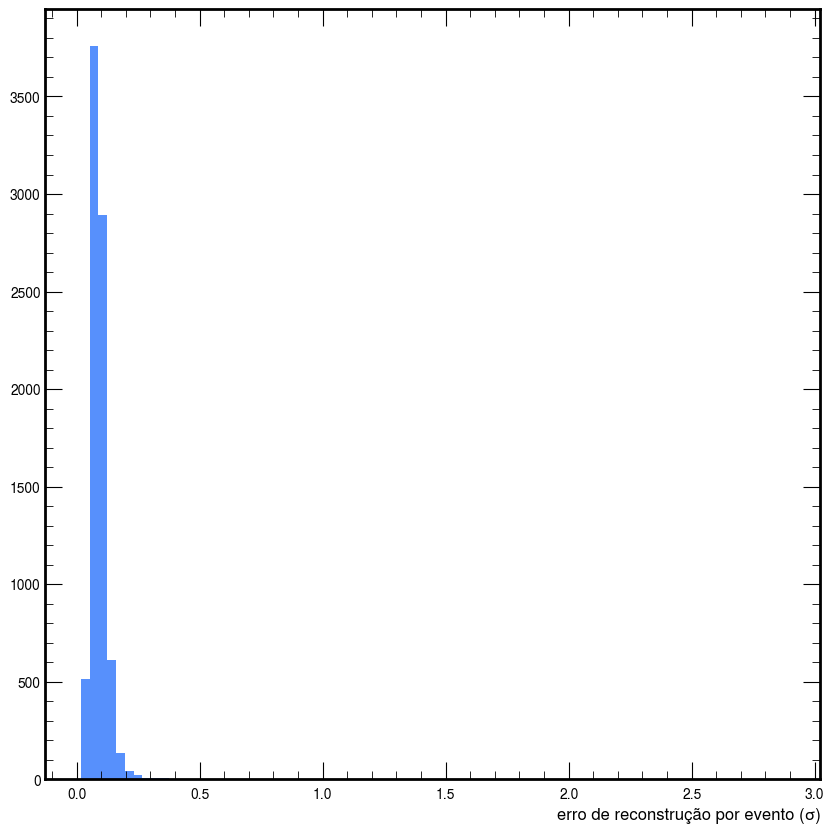

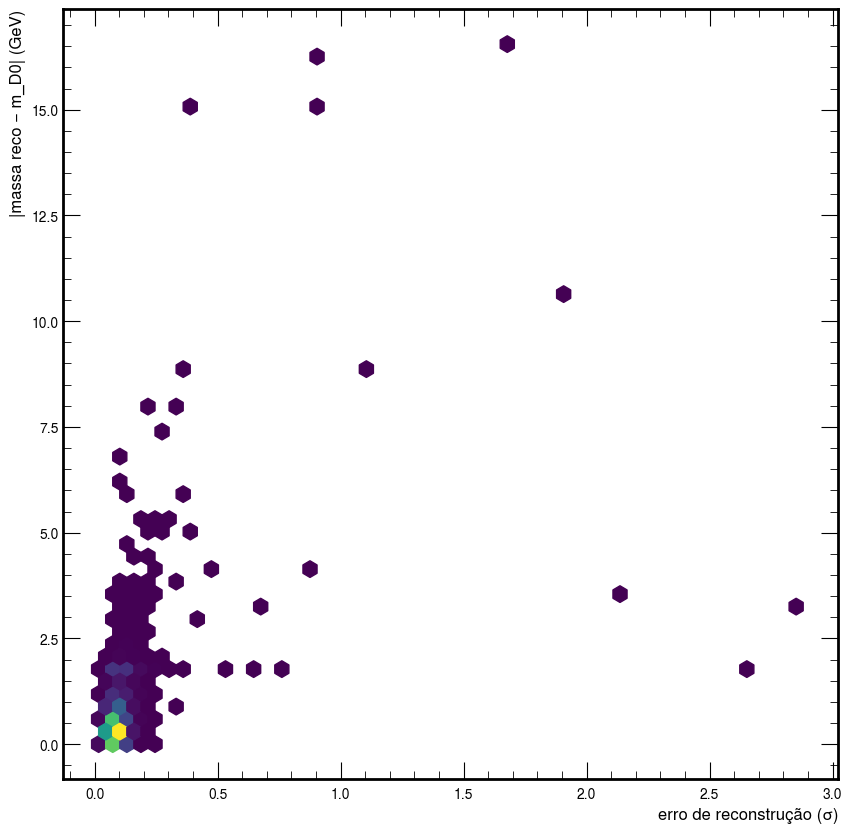

25% melhor reconstruídos: massa σ=0.5781
25% pior  reconstruídos: massa σ=1.4252


In [33]:
import numpy as np, matplotlib.pyplot as plt
model.eval()
with torch.no_grad():
    recon = model(x_test.float())[0]

err    = (recon - x_test).pow(2).mean(dim=1).sqrt().cpu().numpy()        # erro por evento (σ)
m_in   = torch.sqrt(torch.clamp(mass_func(denormalize(x_test)), min=0)).cpu().numpy()
m_reco = torch.sqrt(torch.clamp(mass_func(denormalize(recon)),  min=0)).cpu().numpy()

print(f"massa real:        média={m_in.mean():.4f}  σ={m_in.std():.4f}")
print(f"massa reconstruída: média={m_reco.mean():.4f}  σ={m_reco.std():.4f}  (alvo {mass_D0})")

plt.hist(err, bins=80); plt.xlabel('erro de reconstrução por evento (σ)'); plt.show()

mass_err = np.abs(m_reco - mass_D0)
plt.hexbin(err, mass_err, gridsize=50, mincnt=1)
plt.xlabel('erro de reconstrução (σ)'); plt.ylabel('|massa reco − m_D0| (GeV)'); plt.show()

q1, q3 = np.quantile(err, [0.25, 0.75])
print(f"25% melhor reconstruídos: massa σ={m_reco[err<=q1].std():.4f}")
print(f"25% pior  reconstruídos: massa σ={m_reco[err>=q3].std():.4f}")

In [34]:
import numpy as np
model.eval()

# 1. a janela vem dos DADOS REAIS, não de um chute
m_real = torch.sqrt(torch.clamp(mass_func(denormalize(x_test)), min=0)).cpu().numpy()
mu_r, sig_r = m_real.mean(), m_real.std()
print(f"massa real: média={mu_r:.4f}  σ={sig_r:.4f}")

# 2. massa dos eventos gerados
m_gen = torch.sqrt(torch.clamp(mass_func(generated_data_denormalized), min=0)).cpu().numpy()

# 3. fração dentro da janela de ±3σ do pico real
for k in (1, 2, 3):
    lo, hi = mu_r - k*sig_r, mu_r + k*sig_r
    frac_gen  = np.mean((m_gen  >= lo) & (m_gen  <= hi))
    frac_real = np.mean((m_real >= lo) & (m_real <= hi))   # referência: quanto do próprio real cai aí
    print(f"±{k}σ [{lo:.3f}, {hi:.3f}]: gerados {100*frac_gen:.1f}%  (real {100*frac_real:.1f}%)")

massa real: média=1.8676  σ=0.0202
±1σ [1.847, 1.888]: gerados 2.8%  (real 77.1%)
±2σ [1.827, 1.908]: gerados 5.7%  (real 94.5%)
±3σ [1.807, 1.928]: gerados 8.5%  (real 98.4%)


massa real:        média=1.8676  σ=0.0202
massa reconstruída: média=1.8733  σ=0.9062  (alvo 1.8648)


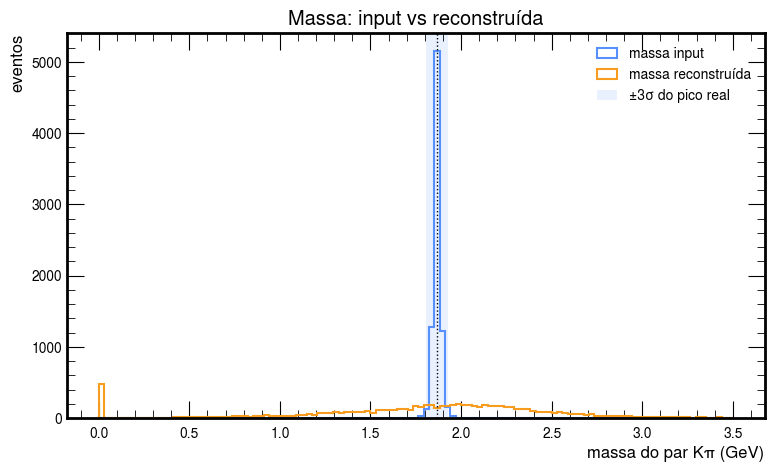

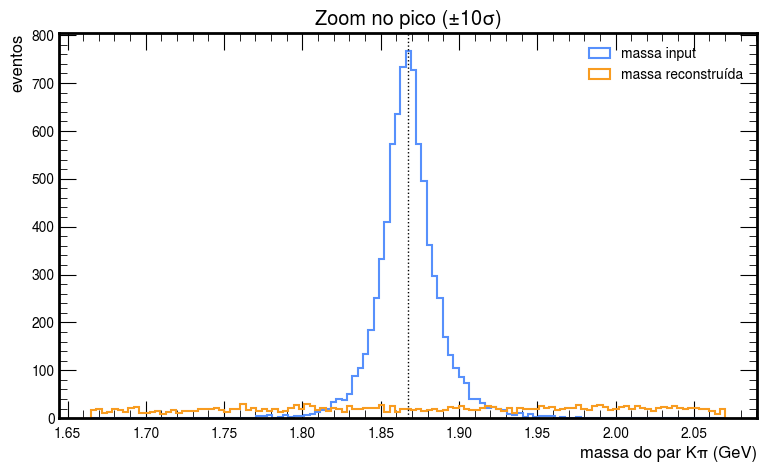

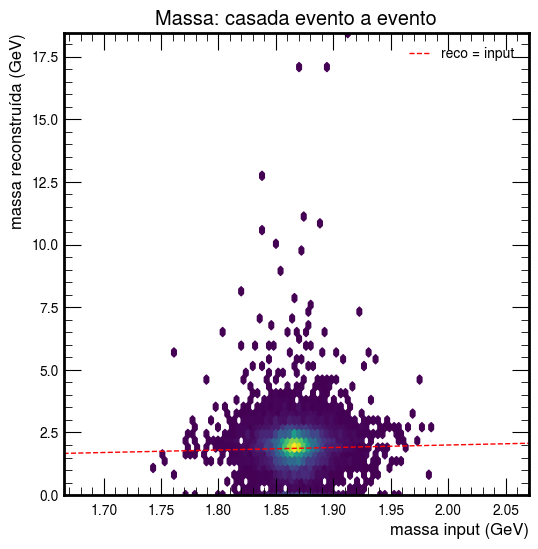

In [40]:
import numpy as np, matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    recon_test, _, _, _ = model(x_test.float())

m_real  = torch.sqrt(torch.clamp(mass_func(denormalize(x_test)),    min=0)).cpu().numpy()
m_recon = torch.sqrt(torch.clamp(mass_func(denormalize(recon_test)), min=0)).cpu().numpy()

mu_r, sig_r = m_real.mean(), m_real.std()
print(f"massa real:        média={m_real.mean():.4f}  σ={m_real.std():.4f}")
print(f"massa reconstruída: média={m_recon.mean():.4f}  σ={m_recon.std():.4f}  (alvo {mass_D0})")

# painel 1: visão ampla, para ver o quanto a reconstruída espalha
plt.figure(figsize=(9,5))
lo, hi = 0.0, 3.5
bins = np.linspace(lo, hi, 120)
plt.hist(m_real,  bins=bins, histtype='step', label='massa input', linewidth=1.5)
plt.hist(m_recon, bins=bins, histtype='step', label='massa reconstruída', linewidth=1.5)
plt.axvline(mu_r, color='k', ls=':', lw=1)
plt.axvspan(mu_r-3*sig_r, mu_r+3*sig_r, alpha=0.12, label='±3σ do pico real')
plt.xlabel('massa do par Kπ (GeV)'); plt.ylabel('eventos'); plt.legend(); plt.title('Massa: input vs reconstruída'); plt.show()

# painel 2: zoom na região do pico, mesma régua dos seus dois histogramas
plt.figure(figsize=(9,5))
bins_z = np.linspace(mu_r-10*sig_r, mu_r+10*sig_r, 120)
plt.hist(m_real,  bins=bins_z, histtype='step', label='massa input', linewidth=1.5)
plt.hist(m_recon, bins=bins_z, histtype='step', label='massa reconstruída', linewidth=1.5)
plt.axvline(mu_r, color='k', ls=':', lw=1)
plt.xlabel('massa do par Kπ (GeV)'); plt.ylabel('eventos'); plt.legend(); plt.title('Zoom no pico (±10σ)'); plt.show()

# correlação evento a evento: a massa reconstruída segue a do input?
plt.figure(figsize=(6,6))
plt.hexbin(m_real, m_recon, gridsize=60, mincnt=1)
lims = [mu_r-10*sig_r, mu_r+10*sig_r]
plt.plot(lims, lims, 'r--', lw=1, label='reco = input')
plt.xlim(lims); plt.ylim(min(m_recon.min(), lims[0]), m_recon.max())
plt.xlabel('massa input (GeV)'); plt.ylabel('massa reconstruída (GeV)'); plt.legend(); plt.title('Massa: casada evento a evento'); plt.show()

massa input:   média=1.8676  σ=0.0202
massa gerada:  média=1.8927  σ=0.8888  (alvo 1.8648)
gerados com m² < 0 (não-físicos): 5.6%


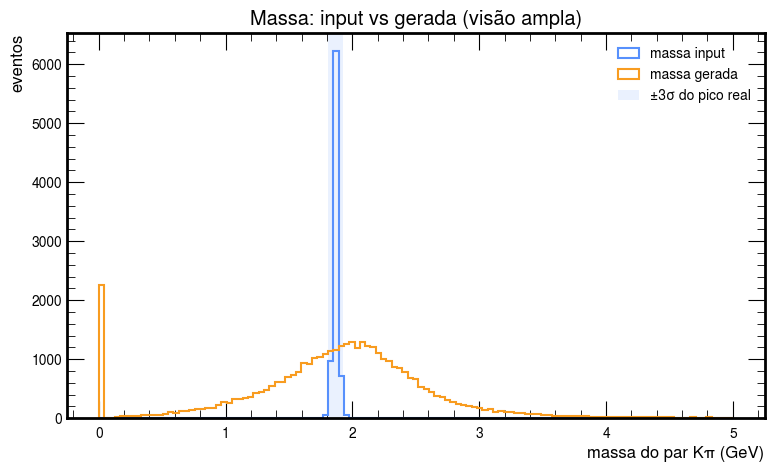

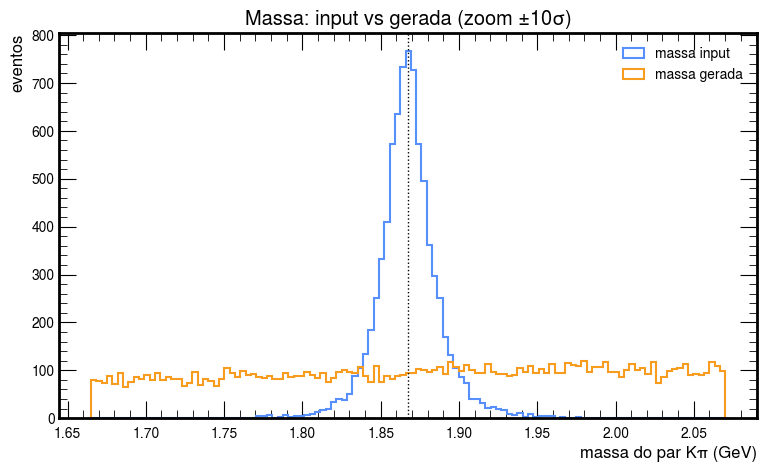

In [41]:
import numpy as np, matplotlib.pyplot as plt

m_real = torch.sqrt(torch.clamp(mass_func(denormalize(x_test)),        min=0)).cpu().numpy()
m_gen  = torch.sqrt(torch.clamp(mass_func(generated_data_denormalized), min=0)).cpu().numpy()

mu_r, sig_r = m_real.mean(), m_real.std()
n_neg = np.mean(mass_func(generated_data_denormalized).cpu().numpy() < 0)
print(f"massa input:   média={m_real.mean():.4f}  σ={m_real.std():.4f}")
print(f"massa gerada:  média={m_gen.mean():.4f}  σ={m_gen.std():.4f}  (alvo {mass_D0})")
print(f"gerados com m² < 0 (não-físicos): {100*n_neg:.1f}%")

# visão ampla — o quanto a gerada espalha
plt.figure(figsize=(9,5))
lo, hi = 0, 5
bins = np.linspace(lo, hi, 120)
plt.hist(m_real, bins=bins, histtype='step', linewidth=1.5, label='massa input')
plt.hist(m_gen,  bins=bins, histtype='step', linewidth=1.5, label='massa gerada')
plt.axvspan(mu_r-3*sig_r, mu_r+3*sig_r, alpha=0.12, label='±3σ do pico real')
plt.xlabel('massa do par Kπ (GeV)'); plt.ylabel('eventos')
plt.legend(); plt.title('Massa: input vs gerada (visão ampla)'); plt.show()

# zoom no pico — escala dos 20 MeV do pico real
plt.figure(figsize=(9,5))
bins_z = np.linspace(mu_r-10*sig_r, mu_r+10*sig_r, 120)
plt.hist(m_real, bins=bins_z, histtype='step', linewidth=1.5, label='massa input')
plt.hist(m_gen,  bins=bins_z, histtype='step', linewidth=1.5, label='massa gerada')
plt.axvline(mu_r, color='k', ls=':', lw=1)
plt.xlabel('massa do par Kπ (GeV)'); plt.ylabel('eventos')
plt.legend(); plt.title('Massa: input vs gerada (zoom ±10σ)'); plt.show()